In [3]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils

In [5]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          # GODMAX/notebooks/diagnostics
DEVELOP = HERE.parents[2]        # develop/

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=3000.0)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 5
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 5
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


nell = 15, ell range [90.4, 2269.7]
nbar_lens_bins [gal/arcmin²]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots


In [12]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


## Here I will highlight the current issue we have with the covariance matrix. It is PSD for a single probe, but not for multi probe.

Data vector shape : (150,)   (10 bin-combos × 15 ell bins)
Entries:
  [ 0]  gy  bin_1_0
  [ 1]  gy  bin_2_0
  [ 2]  gy  bin_3_0
  [ 3]  gy  bin_4_0
  [ 4]  gy  bin_5_0
  [ 5]  gg  bin_1_1
  [ 6]  gg  bin_2_2
  [ 7]  gg  bin_3_3
  [ 8]  gg  bin_4_4
  [ 9]  gg  bin_5_5

Covariance matrix shape : (150, 150)
Count per probe         : {'gy': 5, 'gg': 5}
Min eigenvalue          : -6.813e-27
N negative eigenvalues  : 7


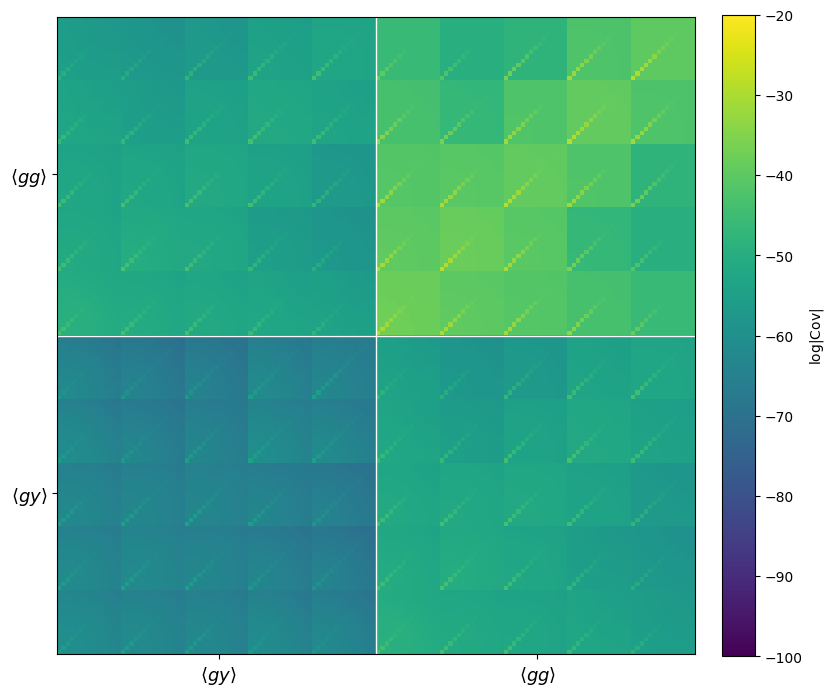

Data vector shape : (75,)   (5 bin-combos × 15 ell bins)
Entries:
  [ 0]  gg  bin_1_1
  [ 1]  gg  bin_2_2
  [ 2]  gg  bin_3_3
  [ 3]  gg  bin_4_4
  [ 4]  gg  bin_5_5

Covariance matrix shape : (75, 75)
Count per probe         : {'gg': 5}
Min eigenvalue          : 3.871e-20
N negative eigenvalues  : 0


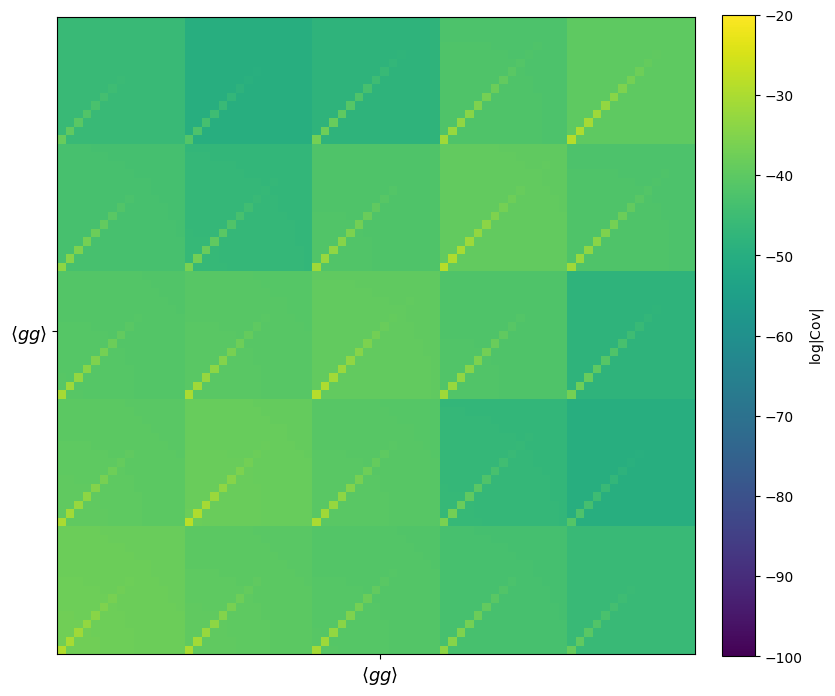

In [ ]:
# ── Define probes ─────────────────────────────────────────────────────────────
probes_arr = ['gy','gg']          
                                                                                                                                                            
# ── Data vector ───────────────────────────────────────────────────────────────                                                                            
dv, entries, nell = diag_utils.build_data_vector(                                                                                                           
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    key='tot_ellsurvey',       # 'tot_plus_noise_ellsurvey' for signal+noise                                                                                
)                                                                                                                                                           
                                                                                                                                                        
print(f"Data vector shape : {dv.shape}   ({len(entries)} bin-combos × {nell} ell bins)")                                                                    
print("Entries:")                                                                                                                                         
for i, (probe, (b1, b2)) in enumerate(entries):                                                                                                             
    print(f"  [{i:2d}]  {probe}  bin_{b1}_{b2}")                                                                                                            
                                                                                                                                                            
# ── Covariance matrix ─────────────────────────────────────────────────────────                                                                            
cov, entries, count_per_probe, nell = diag_utils.build_cov_matrix(                                                                                          
    cov_test.covtot_dict,                                                                                                                                   
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    warn_missing=True,                                                                                                                                      
)                                                                                                                                                         

print(f"\nCovariance matrix shape : {cov.shape}")                                                                                                           
print(f"Count per probe         : {dict(zip(probes_arr, count_per_probe))}")
                                                                                                                                                            
eigvals = np.linalg.eigvalsh(cov)                                                                                                                         
print(f"Min eigenvalue          : {eigvals.min():.3e}")                                                                                                     
print(f"N negative eigenvalues  : {(eigvals < 0).sum()}")                                                                                                   

# ── Plot ──────────────────────────────────────────────────────────────────────                                                                            
fig, ax = plt.subplots(figsize=(9, 9))                                                                                                                    
diag_utils.plot_cov_matrix(cov, count_per_probe, probes_arr, nell, ax=ax)                                                                                   
fig.savefig(FIGDIR / f"cov_{'_'.join(probes_arr)}.png", dpi=200, bbox_inches='tight')                                                                       
plt.show()  

# ── Define probes ─────────────────────────────────────────────────────────────
probes_arr = ['gg']          
                                                                                                                                                            
# ── Data vector ───────────────────────────────────────────────────────────────                                                                            
dv, entries, nell = diag_utils.build_data_vector(                                                                                                           
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    key='tot_ellsurvey',       # 'tot_plus_noise_ellsurvey' for signal+noise                                                                                
)                                                                                                                                                           
                                                                                                                                                        
print(f"Data vector shape : {dv.shape}   ({len(entries)} bin-combos × {nell} ell bins)")                                                                    
print("Entries:")                                                                                                                                         
for i, (probe, (b1, b2)) in enumerate(entries):                                                                                                             
    print(f"  [{i:2d}]  {probe}  bin_{b1}_{b2}")                                                                                                            
                                                                                                                                                            
# ── Covariance matrix ─────────────────────────────────────────────────────────                                                                            
cov, entries, count_per_probe, nell = diag_utils.build_cov_matrix(                                                                                          
    cov_test.covtot_dict,                                                                                                                                   
    cov_test.Cl_result_dict,                                                                                                                               
    probes_arr,                                                                                                                                             
    warn_missing=True,                                                                                                                                      
)                                                                                                                                                         

print(f"\nCovariance matrix shape : {cov.shape}")                                                                                                           
print(f"Count per probe         : {dict(zip(probes_arr, count_per_probe))}")
                                                                                                                                                            
eigvals = np.linalg.eigvalsh(cov)                                                                                                                         
print(f"Min eigenvalue          : {eigvals.min():.3e}")                                                                                                     
print(f"N negative eigenvalues  : {(eigvals < 0).sum()}")                                                                                                   

# ── Plot ──────────────────────────────────────────────────────────────────────                                                                            
fig, ax = plt.subplots(figsize=(9, 9))                                                                                                                    
diag_utils.plot_cov_matrix(cov, count_per_probe, probes_arr, nell, ax=ax)                                                                                   
fig.savefig(FIGDIR / f"cov_{'_'.join(probes_arr)}.png", dpi=200, bbox_inches='tight')                                                                       
plt.show()  

### The following cells has several tests that I did to check if there are inconsistencies anywhere.

## 3-D power spectra: shapes and C-S consistency

**Figure 1** — actual `Pk(k, z)` as stored in GODMAX for all six spectra,
at representative redshifts. The shaded band marks the Limber wavenumber
range $k_\ell = (\ell+0.5)/\chi$ for $\ell \in [100, 1200]$.

**Figure 2** — 3-D Cauchy-Schwarz consistency ratios:
$$r = \frac{P_{xy}^2}{P_{xx}\,P_{yy}} \leq 1 \quad \forall\, k,\,z$$
Values $> 1$ signal that the halo model violates C-S at that $(k, z)$,
which propagates directly into a non-PSD covariance matrix.
Three cross-pairs are checked: $(\kappa, y)$, $(g, y)$, $(g, \kappa)$.

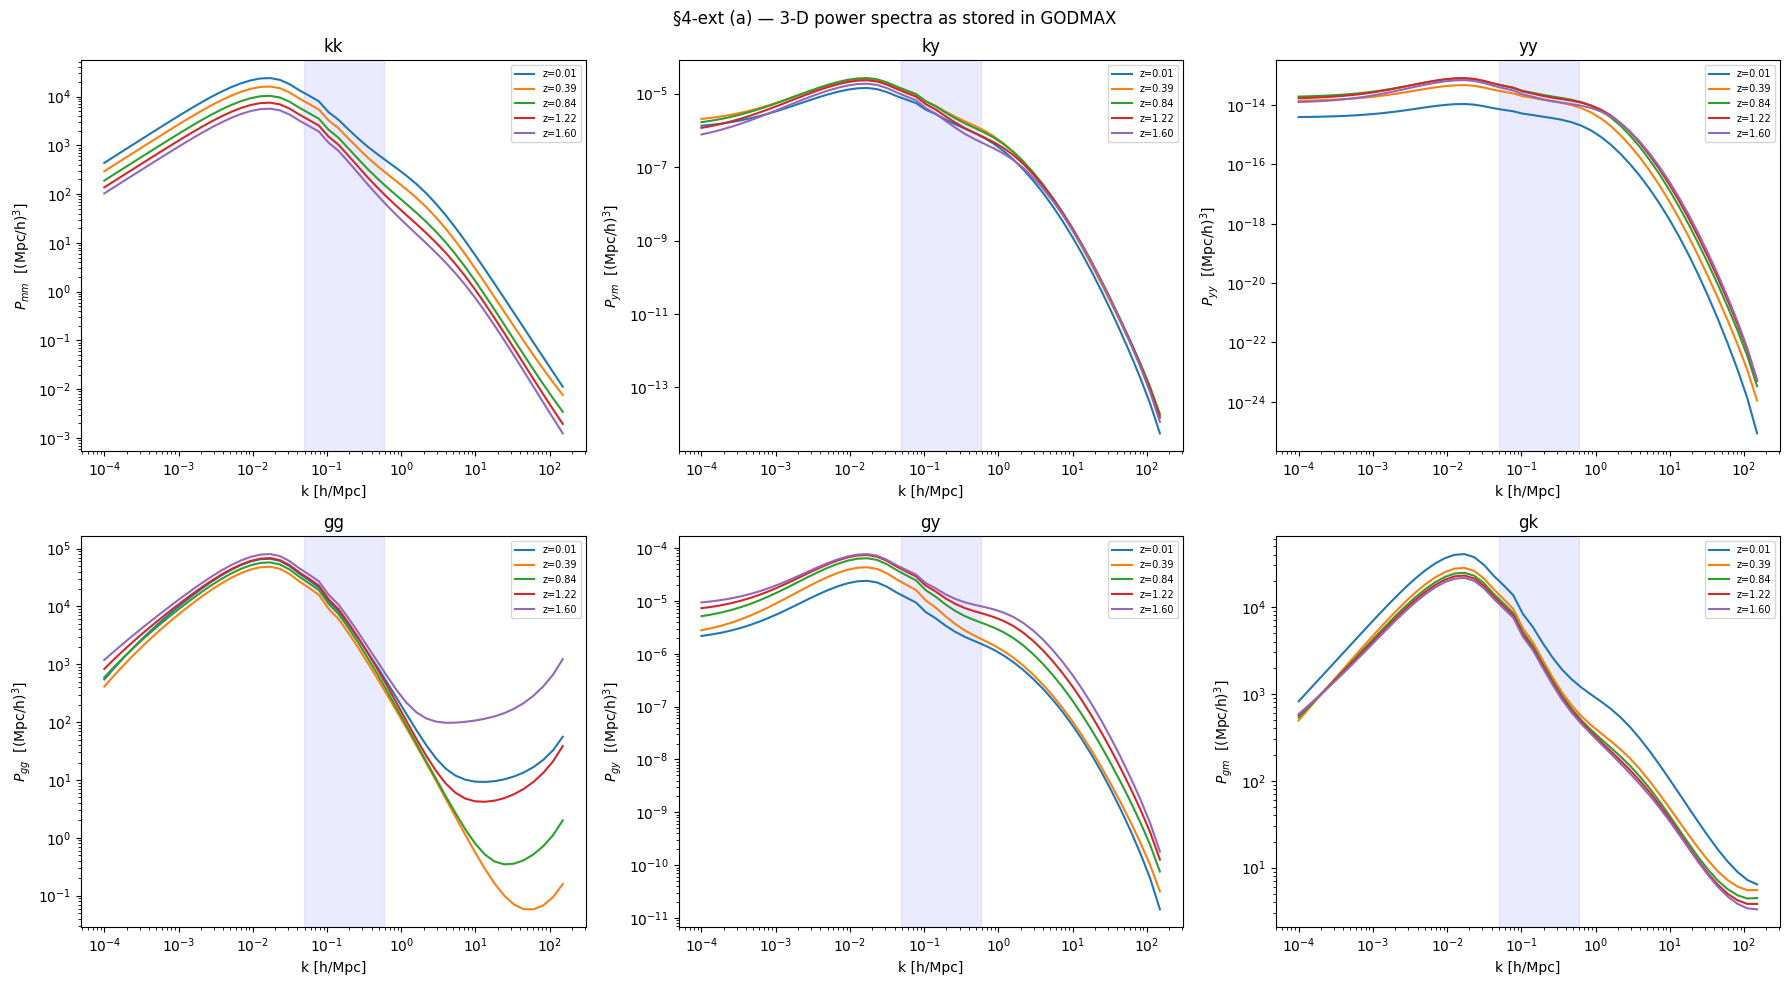

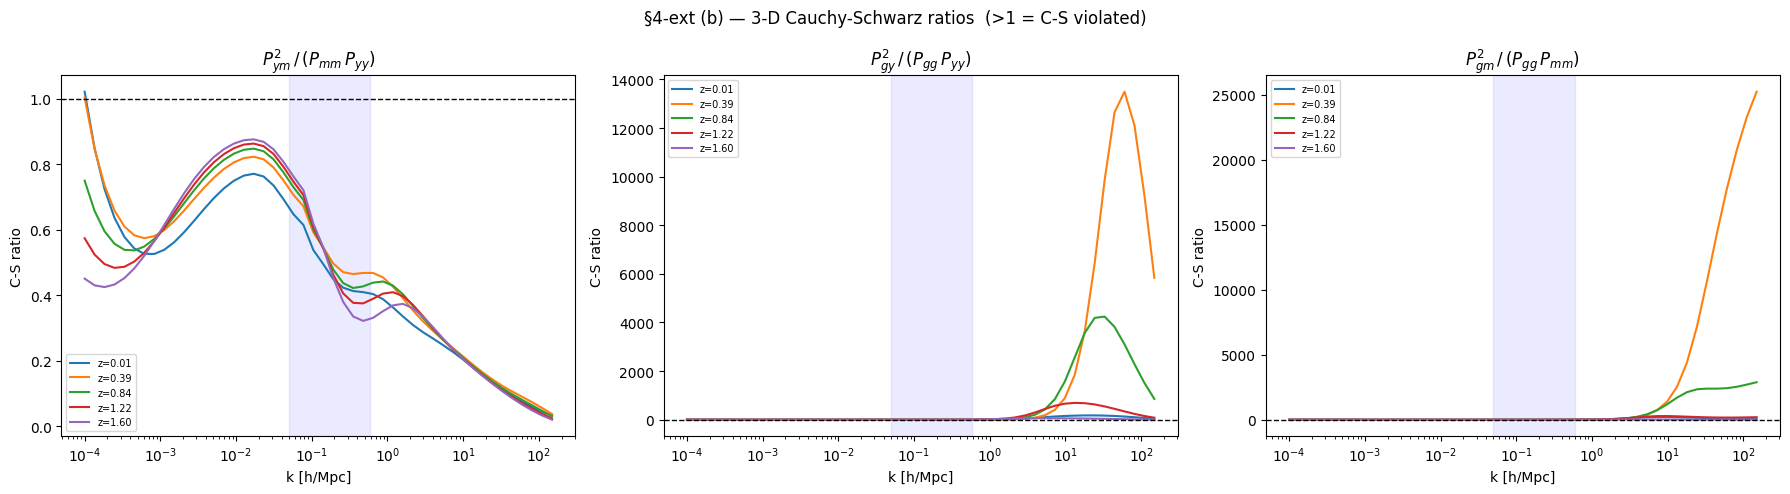

3-D C-S ratios in Limber band ell=[100,1200]:
pair    z       k_lo      k_hi      max ratio     flag
----------------------------------------------------------
ky-kkkk  0.01    3.3160    39.6100   0.2684        ok
ky-kkkk  0.39    0.0950    1.1343    0.5917        ok
ky-kkkk  0.84    0.0494    0.5906    0.7296        ok
ky-kkkk  1.22    0.0377    0.4501    0.7916        ok
ky-kkkk  1.60    0.0316    0.3774    0.8069        ok
gy-gggg  0.01    3.3160    39.6100   177.9792      VIOLATED
gy-gggg  0.39    0.0950    1.1343    2.4058        VIOLATED
gy-gggg  0.84    0.0494    0.5906    1.8106        VIOLATED
gy-gggg  1.22    0.0377    0.4501    2.1226        VIOLATED
gy-gggg  1.60    0.0316    0.3774    3.6139        VIOLATED
gk-gggg  0.01    3.3160    39.6100   209.8790      VIOLATED
gk-gggg  0.39    0.0950    1.1343    6.9297        VIOLATED
gk-gggg  0.84    0.0494    0.5906    3.1930        VIOLATED
gk-gggg  1.22    0.0377    0.4501    2.3603        VIOLATED
gk-gggg  1.60    0.0316    0.3

In [7]:
# ── Common grids ─────────────────────────────────────────────────────────────
kPk    = np.array(Cls_test.kPk_array)       # (nk,)
z_th   = np.array(Cls_test.z_array)          # (nz,)
nz_hm  = len(z_th)
z_sel  = np.unique([0, nz_hm//4, nz_hm//2, 3*nz_hm//4, nz_hm-1])
chi_arr = np.array(Cls_test.chi_array)       # (nz,)
jz_mid  = z_sel[len(z_sel)//2]

# ── Actual 3-D spectra as stored in GODMAX ───────────────────────────────────
Pk3d = {
    'kk': np.array(Cls_test.Pmm_tot_mat),      # (nk, nz)  P_mm used for C_kk
    'ky': np.array(Cls_test.Pym_tot_mat),      # (nk, nz)  P_ym used for C_ky
    'yy': np.array(Cls_test.Pyy_tot_kz_mat),  # (nk, nz)  P_yy used for C_yy
    'gg': np.array(Cls_test.Pgg_tot_mat),      # (nk, nz)  P_gg used for C_gg
    'gy': np.array(Cls_test.Pgy_tot_mat),      # (nk, nz)  P_gy used for C_gy
    'gk': np.array(Cls_test.Pgm_tot_mat),      # (nk, nz)  P_gm used for C_gk
}
ylabels = {
    'kk': r'$P_{mm}$  [(Mpc/h)$^3$]',
    'ky': r'$P_{ym}$  [(Mpc/h)$^3$]',
    'yy': r'$P_{yy}$  [(Mpc/h)$^3$]',
    'gg': r'$P_{gg}$  [(Mpc/h)$^3$]',
    'gy': r'$P_{gy}$  [(Mpc/h)$^3$]',
    'gk': r'$P_{gm}$  [(Mpc/h)$^3$]',
}

# ── Figure 1: actual Pk shapes ───────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
fig1.suptitle('§4-ext (a) — 3-D power spectra as stored in GODMAX', fontsize=12)

for ax, probe in zip(axes1.ravel(), ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']):
    for jz in z_sel:
        ax.loglog(kPk, np.clip(Pk3d[probe][:, jz], 1e-40, None),
                  label=f'z={z_th[jz]:.2f}')
    # Limber band for ell=[100,1200] at jz_mid
    chi_z = chi_arr[jz_mid]
    ax.axvspan(100.5/max(chi_z, 1.), 1200.5/max(chi_z, 1.), alpha=0.08, color='blue')
    ax.set(xlabel='k [h/Mpc]', ylabel=ylabels[probe], title=probe)
    ax.legend(fontsize=7)

plt.tight_layout()
fig1.savefig(os.path.join(FIGDIR, 'pk3d_allprobes_shapes.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: 3-D C-S ratios ─────────────────────────────────────────────────
# r_ym = P_ym^2 / (P_mm * P_yy)  — uses the SAME spectra that enter C_ky, C_kk, C_yy
# r_gy = P_gy^2 / (P_gg * P_yy)
# r_gm = P_gm^2 / (P_gg * P_mm)
cs_pairs = [
    ('ky', 'kk', 'yy', r'$P_{ym}^2\,/\,(P_{mm}\,P_{yy})$'),
    ('gy', 'gg', 'yy', r'$P_{gy}^2\,/\,(P_{gg}\,P_{yy})$'),
    ('gk', 'gg', 'kk', r'$P_{gm}^2\,/\,(P_{gg}\,P_{mm})$'),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('§4-ext (b) — 3-D Cauchy-Schwarz ratios  (>1 = C-S violated)', fontsize=12)

for ax, (pxy, pxx, pyy, title) in zip(axes2, cs_pairs):
    for jz in z_sel:
        denom = np.clip(Pk3d[pxx][:, jz] * Pk3d[pyy][:, jz], 1e-60, None)
        ratio = Pk3d[pxy][:, jz]**2 / denom
        ax.semilogx(kPk, ratio, label=f'z={z_th[jz]:.2f}')
    chi_z = chi_arr[jz_mid]
    ax.axvspan(100.5/max(chi_z, 1.), 1200.5/max(chi_z, 1.), alpha=0.08, color='blue')
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set(xscale='log', xlabel='k [h/Mpc]', ylabel='C-S ratio', title=title)
    ax.legend(fontsize=7)

plt.tight_layout()
fig2.savefig(os.path.join(FIGDIR, 'pk3d_cs_ratios.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Console: max C-S ratio in the Limber band per probe pair ─────────────────
print('3-D C-S ratios in Limber band ell=[100,1200]:')
print(f'{"pair":<6}  {"z":<6}  {"k_lo":<8}  {"k_hi":<8}  {"max ratio":<12}  flag')
print('-' * 58)
for pxy, pxx, pyy, _ in cs_pairs:
    for jz in z_sel:
        k_lo = 100.5  / max(chi_arr[jz], 1.)
        k_hi = 1200.5 / max(chi_arr[jz], 1.)
        mask = (kPk >= k_lo) & (kPk <= k_hi)
        if not mask.any():
            continue
        denom = np.clip(Pk3d[pxx][mask, jz] * Pk3d[pyy][mask, jz], 1e-60, None)
        ratio = Pk3d[pxy][mask, jz]**2 / denom
        flag = 'VIOLATED' if ratio.max() > 1 else 'ok'
        print(f'{pxy+"-"+pxx+pxx:<6}  {z_th[jz]:<6.2f}  {k_lo:<8.4f}  {k_hi:<8.4f}  {ratio.max():<12.4f}  {flag}')


##  Limber integral validation: manual vs GODMAX `Cl_*_mat`

Replicate `get_Cl_tot` exactly in numpy using `cached_power_spectra` (shape `(nell, nz_for_Cls)`)
and compare against the stored GODMAX arrays for all six probes: **gg, kk, ky, gy, gk, yy**.

Window-function prefactors match `compute_prefac` in `get_Cl_tot` (get_Cls.py line 301):

| probe code | prefactor |
|---|---|
| 0 — κ | `(1+m_b) Wk[b] / χ²` |
| 2 — g | `Wg[b] / (dχ/dz · χ²)` |
| 3 — y | `Wy / χ²` |

Agreement should be at machine-precision level (relative error < 1e-5);
any larger discrepancy signals a mismatch between the cached Pk arrays
and the Cl output matrices.

Probe      max |rel err|    mean |rel err|  note
-----------------------------------------------------------------
kk             8.234e-16         1.810e-16  ok
ky             6.013e-16         1.983e-16  ok
yy             4.584e-16         1.605e-16  ok
gg             7.028e-16         1.493e-16  ok
gy             6.143e-16         1.476e-16  ok
gk             6.687e-16         1.515e-16  ok


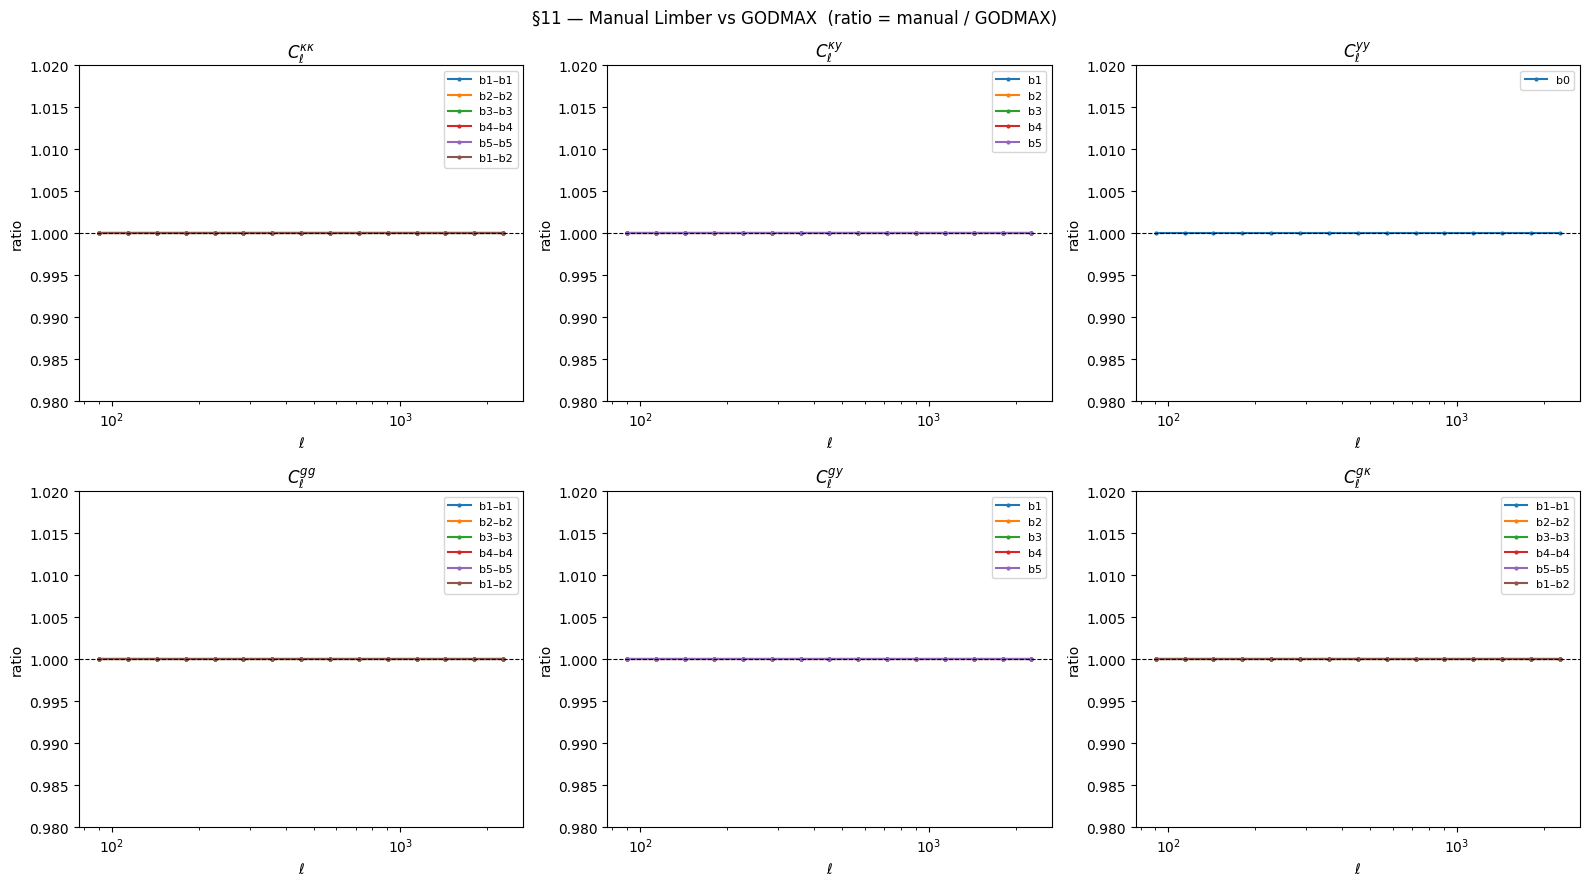

In [9]:
# ── Grid arrays on z_array_for_Cls ──────────────────────────────────────────
z_cls   = np.array(Cls_test.z_array_for_Cls)       # (nz_for_Cls,)
chi_cls = np.array(Cls_test.chi_array_for_Cls)      # (nz_for_Cls,)
dchi_dz = np.array(Cls_test.dchi_dz_array_for_Cls)  # (nz_for_Cls,)
ell_arr = np.array(Cls_test.ell_array)               # (nell,)

# ── Window functions (raw; prefactors applied below) ────────────────────────
Wk_all  = np.array(Cls_test.Wk_mat)                  # (nbins,     nz_for_Cls)
Wg_all  = np.array(Cls_test.Wg_mat)                  # (nbins_lens, nz_for_Cls)
Wy      = np.array(Cls_test.Wy_array)                 # (nz_for_Cls,)
mb      = np.array(Cls_test.mult_shear_bias_array)    # (nbins,) -- usually zeros

# ── Prefactors: compute_prefac in get_Cl_tot (get_Cls.py line 301) ──────────
def fk(jb): return (1.0 + mb[jb]) * Wk_all[jb] / chi_cls**2          # probe 0
def fg(jb): return Wg_all[jb] / (dchi_dz * chi_cls**2)                # probe 2
fy       = Wy / chi_cls**2                                             # probe 3

# ── Cached 3D power spectra on (nell, nz_for_Cls) ───────────────────────────
Pk = {
    'kk': np.array(Cls_test.cached_power_spectra[0, 0]),  # P_mm
    'ky': np.array(Cls_test.cached_power_spectra[0, 3]),  # P_ym
    'yy': np.array(Cls_test.cached_power_spectra[3, 3]),  # P_yy
    'gg': np.array(Cls_test.cached_power_spectra[2, 2]),  # P_gg
    'gy': np.array(Cls_test.cached_power_spectra[2, 3]),  # P_gy
    'gk': np.array(Cls_test.cached_power_spectra[2, 0]),  # P_gm
}

# ── Limber integrator: exact replica of get_Cl_tot's trapezoid ──────────────
def manual_cl(W1, W2, Pk_mat):
    """Cl[ell] = trapz( W1*W2*chi^2*dchi_dz*Pk, dz )  shape: (nell,)"""
    integrand = (W1 * W2 * chi_cls**2 * dchi_dz)[None, :] * Pk_mat  # (nell, nz)
    return np.trapezoid(integrand, z_cls, axis=1)

nbins      = Cls_test.nbins
nbins_lens = Cls_test.nbins_lens

# ── Compute manual Cls for every bin combo ───────────────────────────────────
man = {}
man['kk'] = np.array([[manual_cl(fk(b1), fk(b2), Pk['kk'])
                        for b2 in range(nbins)] for b1 in range(nbins)])          # (nb, nb, nell)
man['ky'] = np.array([manual_cl(fk(b), fy, Pk['ky']) for b in range(nbins)])      # (nb, nell)
man['yy'] = manual_cl(fy, fy, Pk['yy'])                                            # (nell,)
man['gg'] = np.array([[manual_cl(fg(b1), fg(b2), Pk['gg'])
                        for b2 in range(nbins_lens)] for b1 in range(nbins_lens)]) # (nb_l, nb_l, nell)
man['gy'] = np.array([manual_cl(fg(b), fy, Pk['gy']) for b in range(nbins_lens)]) # (nb_l, nell)
man['gk'] = np.array([[manual_cl(fg(b1), fk(b2), Pk['gk'])
                        for b2 in range(nbins)] for b1 in range(nbins_lens)])      # (nb_l, nb, nell)

# ── GODMAX reference arrays ──────────────────────────────────────────────────
# shapes: kk (nell,nb,nb), ky (nell,nb), yy (nell,)
#         gg (nell,nb_l,nb_l), gy (nell,nb_l), gk (nell,nb_l,nb)
ref = {
    'kk': np.array(Cls_test.Cl_kappa_kappa_tot_mat),  # (nell, nb, nb)
    'ky': np.array(Cls_test.Cl_kappa_y_tot_mat),       # (nell, nb)
    'yy': np.array(Cls_test.Cl_y_y_signal_mat),        # (nell,)
    'gg': np.array(Cls_test.Cl_gal_gal_tot_mat),       # (nell, nb_l, nb_l)
    'gy': np.array(Cls_test.Cl_gal_y_tot_mat),         # (nell, nb_l)
    'gk': np.array(Cls_test.Cl_gal_kappa_tot_mat),     # (nell, nb_l, nb)
}
# Transpose manual arrays to (nell, ...) for direct comparison
man_t = {
    'kk': man['kk'].transpose(2, 0, 1),   # (nell, nb, nb)
    'ky': man['ky'].T,                     # (nell, nb)
    'yy': man['yy'],                        # (nell,)
    'gg': man['gg'].transpose(2, 0, 1),    # (nell, nb_l, nb_l)
    'gy': man['gy'].T,                     # (nell, nb_l)
    'gk': man['gk'].transpose(2, 0, 1),   # (nell, nb_l, nb)
}

# ── Relative error diagnostic ────────────────────────────────────────────────
thresh = 1e-20   # ignore near-zero Cls
probe_labels = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']
probe_titles = {
    'kk': r'$C_\ell^{\kappa\kappa}$',
    'ky': r'$C_\ell^{\kappa y}$',
    'yy': r'$C_\ell^{yy}$',
    'gg': r'$C_\ell^{gg}$',
    'gy': r'$C_\ell^{gy}$',
    'gk': r'$C_\ell^{g\kappa}$',
}

print("{:<6}  {:>16}  {:>16}  {}".format("Probe", "max |rel err|", "mean |rel err|", "note"))
print('-' * 65)
for p in probe_labels:
    m, r = man_t[p].ravel(), ref[p].ravel()
    mask = np.abs(r) > thresh
    if mask.any():
        rel = np.abs(m[mask] - r[mask]) / np.abs(r[mask])
        note = 'WARN: >1e-4' if rel.max() > 1e-4 else 'ok'
        print(f'{p:<6}  {rel.max():>16.3e}  {rel.mean():>16.3e}  {note}')
    else:
        print(f"{p:<6}  N/A (all zero)")

# ── Comparison plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('§11 — Manual Limber vs GODMAX  (ratio = manual / GODMAX)', fontsize=12)

for ax, p in zip(axes.ravel(), probe_labels):
    m, r = man_t[p], ref[p]
    # Collapse bin axes: iterate over first extra dim if present
    if m.ndim == 1:
        combos = [(m, r, 'b0')]
    elif m.ndim == 2:
        combos = [(m[:, jb], r[:, jb], f'b{jb+1}') for jb in range(m.shape[1])]
    else:  # (nell, b1, b2) -- plot diagonal + (0,1) only
        combos = [(m[:, jb, jb], r[:, jb, jb], f'b{jb+1}–b{jb+1}')
                   for jb in range(m.shape[1])]
        if m.shape[1] > 1 and m.shape[2] > 0:
            combos.append((m[:, 0, 1], r[:, 0, 1], 'b1–b2'))

    for mc, rc, lbl in combos:
        mask = np.abs(rc) > thresh
        ratio = np.where(mask, mc / np.where(mask, rc, 1.0), np.nan)
        ax.plot(ell_arr, ratio, marker='.', ms=4, label=lbl)

    ax.axhline(1.0, ls='--', color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('ratio')
    ax.set_title(probe_titles[p])
    ax.legend(fontsize=8)
    ax.set_ylim(0.98, 1.02)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'limber_validation_allprobes.png'), dpi=150, bbox_inches='tight')
plt.show()


## Angular Cauchy-Schwarz consistency

For a Gaussian random field, the signal power spectra must satisfy
$$C_{xy}^2(\ell) \leq C_{xx}(\ell)\,C_{yy}(\ell) \quad \forall\,\ell$$
for every pair of fields $(x, y)$.  Violation means the angular power spectra
are internally inconsistent and the Gaussian covariance matrix will not be PSD.

Checked here for the three cross-pairs that involve the tSZ field and
galaxy–lensing cross: $(\kappa y)$, $(gy)$, $(g\kappa)$, per tomographic bin.
All quantities are taken directly from `Cl_result_dict` — no modification applied.

κy  C-S ratios:
  b1: max r=0.3547  at ell=143.2  [ok]
  b2: max r=0.3345  at ell=180.3  [ok]
  b3: max r=0.3591  at ell=227.0  [ok]
  b4: max r=0.3755  at ell=359.7  [ok]
  b5: max r=0.3901  at ell=452.9  [ok]
gy  C-S ratios:
  b1: max r=7.9764  at ell=2269.7  [VIOLATED]
  b2: max r=4.3438  at ell=2269.7  [VIOLATED]
  b3: max r=4.3840  at ell=2269.7  [VIOLATED]
  b4: max r=3.0057  at ell=2269.7  [VIOLATED]
  b5: max r=2.4794  at ell=2269.7  [VIOLATED]
gκ  C-S ratios:
  g1-k1: max r=38.4158  at ell=2269.7  [VIOLATED]
  g1-k2: max r=47.2919  at ell=2269.7  [VIOLATED]
  g1-k3: max r=57.2025  at ell=2269.7  [VIOLATED]
  g1-k4: max r=57.8239  at ell=2269.7  [VIOLATED]
  g1-k5: max r=52.4269  at ell=2269.7  [VIOLATED]
  g2-k1: max r=3.9672  at ell=2269.7  [VIOLATED]
  g2-k2: max r=3.7609  at ell=2269.7  [VIOLATED]
  g2-k3: max r=11.8981  at ell=2269.7  [VIOLATED]
  g2-k4: max r=19.5129  at ell=2269.7  [VIOLATED]
  g2-k5: max r=20.8359  at ell=2269.7  [VIOLATED]
  g3-k1: max r=0.8393  at ell

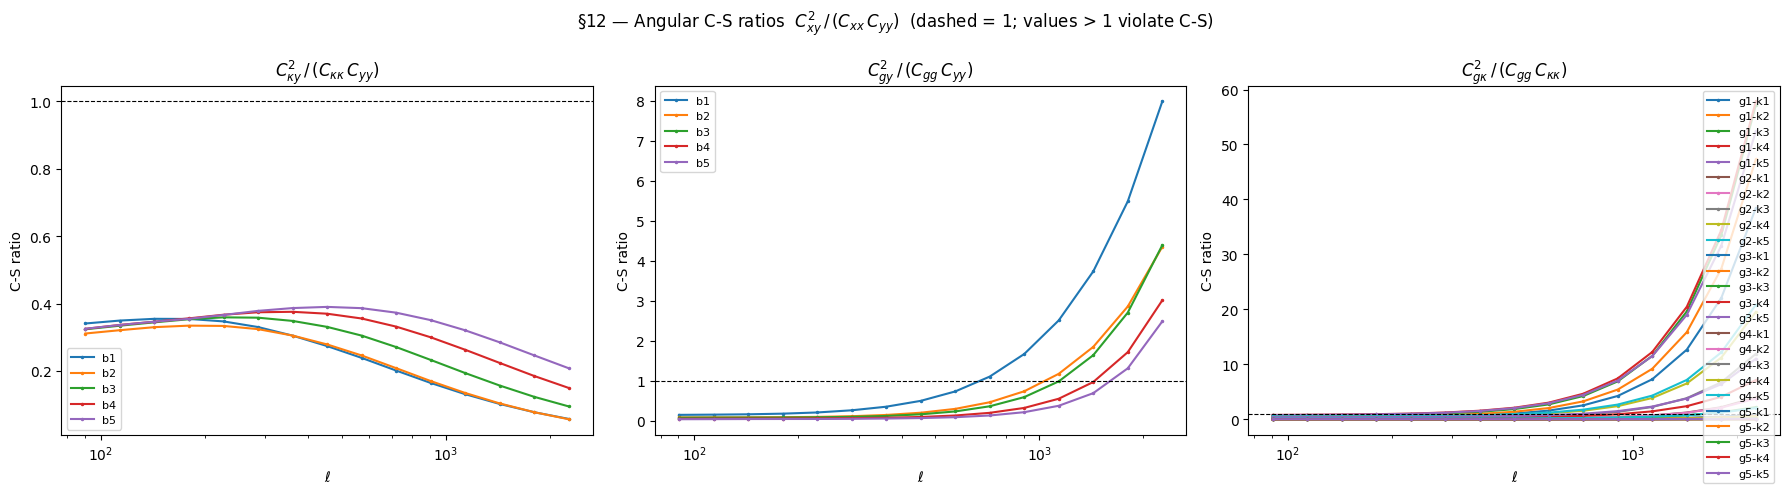

In [10]:
Cyy = ref['yy']          # (nell,)
nbins      = ref['kk'].shape[1]
nbins_lens = ref['gg'].shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    r'§12 — Angular C-S ratios  $C_{xy}^2\,/\,(C_{xx}\,C_{yy})$'
    '  (dashed = 1; values > 1 violate C-S)',
    fontsize=12
)

# ── (a) κy : C_ky^2 / (C_kk * C_yy) ─────────────────────────────────────────
ax = axes[0]
print('κy  C-S ratios:')
for jb in range(nbins):
    Cky = ref['ky'][:, jb]                   # (nell,)
    Ckk = ref['kk'][:, jb, jb]               # auto-bin
    denom = np.clip(Ckk * Cyy, 1e-60, None)
    ratio = Cky**2 / denom
    ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'b{jb+1}')
    imax = np.nanargmax(ratio)
    flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
    print(f'  b{jb+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{\kappa y}^2\,/\,(C_{\kappa\kappa}\,C_{yy})$')
ax.legend(fontsize=8)

# ── (b) gy : C_gy^2 / (C_gg * C_yy) ─────────────────────────────────────────
ax = axes[1]
print('gy  C-S ratios:')
for jb in range(nbins_lens):
    Cgy = ref['gy'][:, jb]
    Cgg = ref['gg'][:, jb, jb]
    denom = np.clip(Cgg * Cyy, 1e-60, None)
    ratio = Cgy**2 / denom
    ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'b{jb+1}')
    imax = np.nanargmax(ratio)
    flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
    print(f'  b{jb+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{gy}^2\,/\,(C_{gg}\,C_{yy})$')
ax.legend(fontsize=8)

# ── (c) gκ : C_gk^2 / (C_gg * C_kk) ─────────────────────────────────────────
ax = axes[2]
print('gκ  C-S ratios:')
for jbl in range(nbins_lens):
    for jbs in range(nbins):
        Cgk = ref['gk'][:, jbl, jbs]
        Cgg = ref['gg'][:, jbl, jbl]
        Ckk = ref['kk'][:, jbs, jbs]
        denom = np.clip(Cgg * Ckk, 1e-60, None)
        ratio = Cgk**2 / denom
        ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'g{jbl+1}-k{jbs+1}')
        imax = np.nanargmax(ratio)
        flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
        print(f'  g{jbl+1}-k{jbs+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{g\kappa}^2\,/\,(C_{gg}\,C_{\kappa\kappa})$')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'angular_cs_ratios.png'), dpi=150, bbox_inches='tight')
plt.show()


## Baryonic Suppression: Where It Is and Is Not Applied
                                                                                                                                       
  The suppression factor is defined as:
                                                                                                                                                            
  $S(k,z) = \frac{P_{\rm halofit}(k,z)}{P_{\rm NFW,tot}(k,z)} = \frac{P_{\rm halofit}}{P_{\rm 1H,NFW} + P_{\rm 2H,NFW}}$                                    
                                                                                                                                                              
  | Spectrum | Suppression applied? | Rationale / Note |                                                                                                      
  |---|---|---|                                                                                                                                             
  | $P_{mm}$ (matter auto) | **Yes** | $P_{\rm dmb} \times S(k,z)$. If `model_matter='halofit'`, $S\equiv 1$ |
  | $P_{gg}$ (galaxy auto) | **Yes** | $(P_{\rm 1H}+P_{\rm 2H})\times S$ |                                                                                    
  | $P_{gm}$ (galaxy $\times$ matter) | **Yes** | $(P_{\rm 1H}+P_{\rm 2H})\times S$ |                                                                         
  | $P_{ge}$ (galaxy $\times$ electrons) | **Yes** | $(P_{\rm 1H}+P_{\rm 2H})\times S$ |                                                                      
  | $P_{ym}$ (tSZ $\times$ matter) | **No** (default) | Only applied if `tSZ_transition_model='response'`; otherwise `poweradd` |                             
  | $P_{yy}$ (tSZ auto) | **No** | Pure $P_{\rm 1H}+P_{\rm 2H}$; suppression never applied |                                                                  
  | $P_{gy}$ (galaxy $\times$ tSZ) | **No** (default) | Same as $P_{ym}$ — `poweradd` only; `response` model applies $S$ |                                    

----------------------------------------------------------------------------------
  > **Design decision tSZ spectra and suppression.**                                                                                                        
  > The `poweradd` model (default) combines 1H and 2H terms as                                                                                                
  > $P = \left(P_{\rm 1H}^\alpha + P_{\rm 2H}^\alpha\right)^{1/\alpha}$                                                                                    
  > and applies **no** suppression factor $S(k,z)$ to tSZ-containing spectra.                                                                                 
  > The `response` model additionally multiplies by $S(k,z)$.                                                                                                 
  > The physical motivation is that the tSZ signal is already sensitive to baryon                                                                             
  > redistribution through the pressure profile directly; $S(k,z)$ was calibrated                                                                             
  > for the matter field, not for $y$. Applying it on top of the baryonified                                                                                
  > pressure profile would double-count baryonic effects.   

## Is the Pressure Profile Baryonified? And Is $P_\mathrm{sup}$ on $P_{gg}$ Physically Correct?
                                                                                      
  ### The pressure profile derivation chain                                                                                                                   
                                                                                                                                                              
  The tSZ signal is built entirely from the BCMP gas model - there is no NFW component anywhere in the $y$ pipeline:                                          
                                                                                                                                                              
  $$                                                                                                                                                          
  \underbrace{(\theta_\mathrm{ej},\,\theta_\mathrm{co},\,\beta)}_{\text{BCMP gas params}}
  \;\longrightarrow\;                                                                                                                                         
  \rho_\mathrm{gas}(r|M,z)                                                                                                                                    
  \;\longrightarrow\;                                                                                                                                         
  T_\mathrm{gas}(r|M,z) \;\text{[HSE + } f_\mathrm{nt}\text{]}                                                                                                
  \;\longrightarrow\;                                                                                                                                         
  P_e(r|M,z)      
  \;\longrightarrow\;                                                                                                                                         
  y_\mathrm{3D}(r|M,z)
  $$                                                                                                                                                          
                  
  The pressure profile is therefore **fully baryonified by construction**. The gas is redistributed by `theta_ej` and `theta_co`, and the resulting electron  
  pressure is what enters the tSZ kernel. NFW plays no role in the $y$ or $\kappa y$ spectra.
                                                                                                                                                              
  ---             

  ### What $P_\mathrm{sup}$ actually is                                                                                                                       
  
  The suppression factor is defined as                                                                                                                        
                  
  $$
  S(k,z) \;\equiv\; \frac{P_\mathrm{halofit}^\mathrm{DM}(k,z)}{P_\mathrm{NFW,\,tot}(k,z)}
  $$                                                                                                                                                          
  
  where the numerator is the **dark-matter-only** nonlinear power spectrum (Takahashi halofit) and the denominator is the **NFW-only halo model** (1h + 2h, no
   gas).          
                                                                                                                                                              
  This is a **halo model accuracy correction** — it absorbs the well-known $\sim$10–20% inaccuracy of the NFW halo model relative to $N$-body results (missing
   substructure, halo exclusion, pseudo-1h terms, etc.).
                                                                                                                                                              
  > **$P_\mathrm{sup}$ is not a baryonic correction.** It does not encode any physics of gas expulsion, AGN feedback, or adiabatic contraction. Those effects 
  are already in the BCMP profiles.
                                                                                                                                                              
  ---             

  ### Is applying $P_\mathrm{sup}$ to $P_{gg}$ physically correct?                                                                                            
  
  **Arguably no**, for two reasons.                                                                                                                           
                  
  #### 1. Calibration mismatch                                                                                                                                
  
  $S(k,z)$ is calibrated against the **matter** power spectrum. Galaxy clustering traces a biased, HOD-selected population:                                   
                  
  $$                                                                                                                                                          
  P_{gg}(k,z) = b_g^2 \, P_{mm}(k,z) + \frac{1}{\bar{n}_g} \quad \text{(schematically)}
  $$                                                                                                                                                          
  
  The halo model inaccuracies absorbed by $S$ (halo exclusion, pseudo-1h, etc.) enter $P_{mm}$ and $P_{gg}$ differently. Applying the same $S$ to both is an  
  approximation without direct $N$-body justification for biased tracers.
                                                                                                                                                              
  #### 2. The 3D Cauchy–Schwarz violation                                                                                                                     
  
  At 3D level, a valid power spectrum matrix requires                                                                                                         
                  
  $$                                                                                                                                                          
  P_{gy}^2(k,z) \;\leq\; P_{gg}(k,z)\cdot P_{yy}(k,z)
  $$                                                                                                                                                          
  
  In GODMAX the spectra are computed as:                                                                                                                      
                  
  | Spectrum | Suppression applied? |                                                                                                                         
  |----------|----------------------|
  | $P_{mm}$ | $\times\, S(k,z)$ |
  | $P_{gm}$ | $\times\, S(k,z)$ |                                                                                                                            
  | $P_{gg}$ | $\times\, S(k,z)$ |
  | $P_{ym}$ | $\times\, 1$ (none) |                                                                                                                          
  | $P_{gy}$ | $\times\, 1$ (none) |                                                                                                                          
  | $P_{yy}$ | $\times\, 1$ (none) |                                                                                                                          
                                                                                                                                                              
  The cross-spectrum $P_{gy}$ receives no suppression because the pressure kernel is fully baryonified. But $P_{gg}$ does. When $S < 1$ (which is the typical 
  case on small scales), the Cauchy–Schwarz ratio becomes
                                                                                                                                                              
  $$              
  \frac{P_{gy}^2}{P_{gg} \cdot P_{yy}} = \frac{P_{gy}^2}{S \cdot P_{gg}^\mathrm{unsup} \cdot P_{yy}} > 1
  $$                                                                                                                                                          
  
  This might violate the positive-semidefiniteness of the $3\times 3$ cross-spectrum matrix and propagates directly into the Gaussian covariance:                  
                  
  $$                                                                                                                                                          
  \mathrm{Cov}(C_\ell^{gy}, C_\ell^{gy}) \;\propto\; C_\ell^{gg} \cdot C_\ell^{yy} + \left(C_\ell^{gy}\right)^2
  $$                                                                                                                                                          
  
  A Limber-projected violation at the 3D level can produce negative eigenvalues in the angular covariance matrix.                                             
                  
  ---                                                                                                                                                         
                  
  ### Summary

  | Spectrum | $P_\mathrm{sup}$ status | Physical justification |                                                                                             
  |----------|--------------------------|------------------------|
  | $P_{mm}$ | Applied | DM halo model correction — exact calibration target |                                                                                
  | $P_{gm}$, $P_{gg}$ | Applied | Approximate — $S$ not calibrated for biased tracers |                                                                      
  | $P_{ym}$, $P_{gy}$, $P_{yy}$ | Not applied | Pressure is fully baryonified; no NFW → no correction needed |                                               

----------------------------------------------------------------------------------                                                             
  > **Consequence**: applying $S$ to $P_{gg}$ but not to $P_{gy}$ or $P_{yy}$ creates an **asymmetric suppression** that breaks the 3D Cauchy–Schwarz inequality on scales where $S(k,z) < 1$, potentially causing non-positive-semidefinite covariance matrices.                                                 
                                                                                                                                                              
  **Proposed fix options:**
  - **Try A** — Do not apply $P_\mathrm{sup}$ to $P_{gg}$ (treat the galaxy bias as absorbing the halo model inaccuracy).
  - **Try B** — Also apply $S$ to $P_{gy}$ and $P_{gy}$ cross-terms (requires a justification for why the matter-field correction applies to galaxy–$y$       
  correlations).                                                                                      

z=0.01: Pmm_sup in ell=[100,1200] → k=[3.316,39.610]: min=1.068, max=1.399, median=1.099
z=0.39: Pmm_sup in ell=[100,1200] → k=[0.095,1.134]: min=0.883, max=0.914, median=0.889
z=0.84: Pmm_sup in ell=[100,1200] → k=[0.049,0.591]: min=0.899, max=0.968, median=0.934
z=1.22: Pmm_sup in ell=[100,1200] → k=[0.038,0.450]: min=0.951, max=0.980, median=0.963
z=1.60: Pmm_sup in ell=[100,1200] → k=[0.032,0.377]: min=0.980, max=0.991, median=0.985


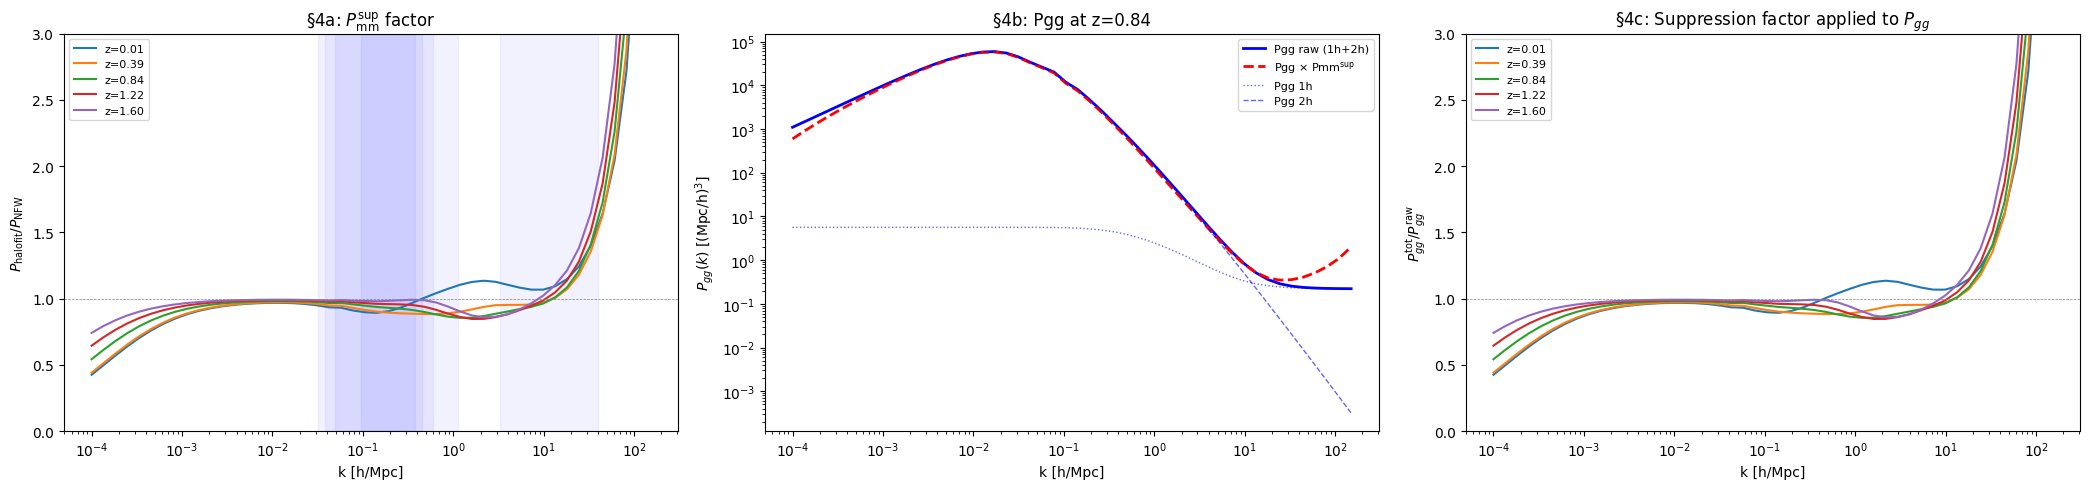

In [17]:
Pmm_sup = np.array(Cls_test.Pmm_sup_tot_mat)  # (nk, nz)
kPk = np.array(Cls_test.kPk_array)

Pgg_1h = np.array(Cls_test.Pgg_1h_kz_mat)   # (nk, nz)
Pgg_2h = np.array(Cls_test.Pgg_2h_kz_mat)   # (nk, nz)
Pgg_raw = Pgg_1h + Pgg_2h                     # before suppression
Pgg_tot = np.array(Cls_test.Pgg_tot_mat)      # after suppression = Pgg_raw * Pmm_sup

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Panel 1: Pmm_sup at several z
for jz in z_sel:
    axes[0].plot(kPk, Pmm_sup[:, jz], label=f'z={z_th[jz]:.2f}')
axes[0].axhline(1.0, color='gray', ls='--', lw=0.5)
axes[0].set(xscale='log', xlabel='k [h/Mpc]', ylabel=r'$P_{\rm halofit}/P_{\rm NFW}$',
            title=r'§4a: $P_{\rm mm}^{\rm sup}$ factor', ylim=(0, 3))
axes[0].legend(fontsize=8)

# Mark the k range probed by ell = [100, 1200] at relevant z
chi_arr = np.array(Cls_test.chi_array)
for jz in z_sel:
    k_lo = 100.5 / max(chi_arr[jz], 1.0)
    k_hi = 1200.5 / max(chi_arr[jz], 1.0)
    axes[0].axvspan(k_lo, k_hi, alpha=0.05, color='blue')

# Panel 2: Pgg with and without suppression
jz_mid = z_sel[len(z_sel)//2]
axes[1].loglog(kPk, Pgg_raw[:, jz_mid], 'b-', lw=2, label='Pgg raw (1h+2h)')
axes[1].loglog(kPk, Pgg_tot[:, jz_mid], 'r--', lw=2, label=r'Pgg $\times$ Pmm$^{\rm sup}$')
axes[1].loglog(kPk, Pgg_1h[:, jz_mid], 'b:', lw=1, alpha=0.6, label='Pgg 1h')
axes[1].loglog(kPk, Pgg_2h[:, jz_mid], 'b--', lw=1, alpha=0.6, label='Pgg 2h')
axes[1].set(xlabel='k [h/Mpc]', ylabel=r'$P_{gg}(k)$ [(Mpc/h)$^3$]',
            title=f'§4b: Pgg at z={z_th[jz_mid]:.2f}')
axes[1].legend(fontsize=8)

# Panel 3: ratio Pgg_tot / Pgg_raw = Pmm_sup effect on galaxy power
for jz in z_sel:
    ratio_sup = np.where(Pgg_raw[:, jz] > 1e-30, Pgg_tot[:, jz] / Pgg_raw[:, jz], np.nan)
    axes[2].semilogx(kPk, ratio_sup, label=f'z={z_th[jz]:.2f}')
axes[2].axhline(1.0, color='gray', ls='--', lw=0.5)
axes[2].set(xlabel='k [h/Mpc]', ylabel=r'$P_{gg}^{\rm tot}/P_{gg}^{\rm raw}$',
            title=r'§4c: Suppression factor applied to $P_{gg}$', ylim=(0, 3))
axes[2].legend(fontsize=8)
plt.tight_layout()

# Print Pmm_sup statistics at relevant k range
for jz in z_sel:
    k_lo = 100.5 / max(chi_arr[jz], 1.0)
    k_hi = 1200.5 / max(chi_arr[jz], 1.0)
    k_mask = (kPk >= k_lo) & (kPk <= k_hi)
    if k_mask.any():
        sup_vals = Pmm_sup[k_mask, jz]
        print(f"z={z_th[jz]:.2f}: Pmm_sup in ell=[100,1200] → k=[{k_lo:.3f},{k_hi:.3f}]: "
              f"min={sup_vals.min():.3f}, max={sup_vals.max():.3f}, median={np.median(sup_vals):.3f}")


S_lz shape : (15, 128)  (nell=15, nz_for_Cls=128)
S_lz range : [0.8462, 2.5160],  mean=0.9438
Fix A: mean Cl_gg ratio (fixA / default) = 1.0780  (> 1 because S < 1)
Fix A: get_cov done.

  fixA  —  probes: ['gy', 'gg']
DV shape : (150,)  (10 bin-combos × 15 ell bins)
  [ 0]  gy  bin_1_0
  [ 1]  gy  bin_2_0
  [ 2]  gy  bin_3_0
  [ 3]  gy  bin_4_0
  [ 4]  gy  bin_5_0
  [ 5]  gg  bin_1_1
  [ 6]  gg  bin_2_2
  [ 7]  gg  bin_3_3
  [ 8]  gg  bin_4_4
  [ 9]  gg  bin_5_5

Cov shape       : (150, 150)
Count per probe : {'gy': 5, 'gg': 5}
Min eigenvalue  : -6.453e-27
N negative eigv : 6


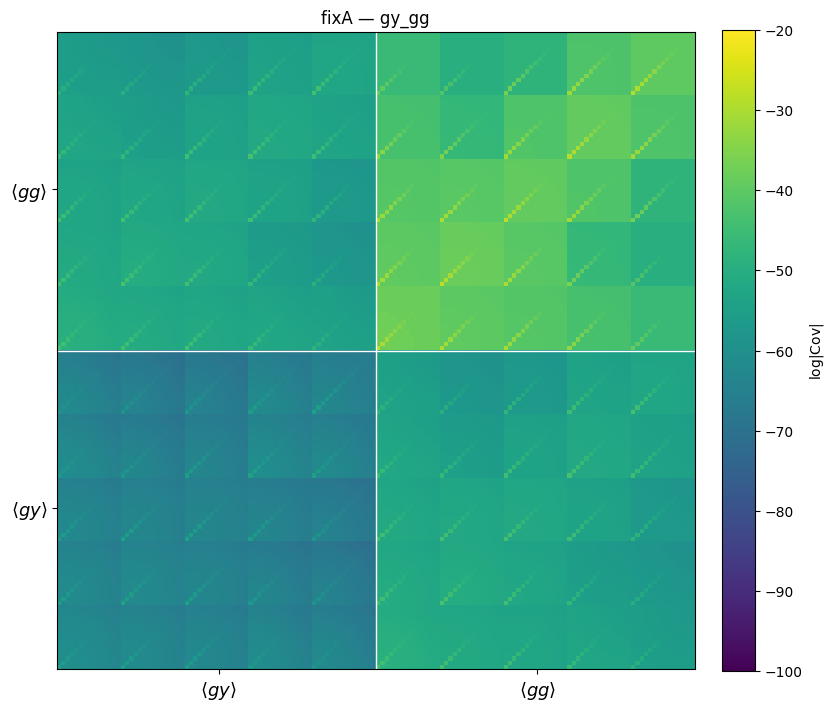

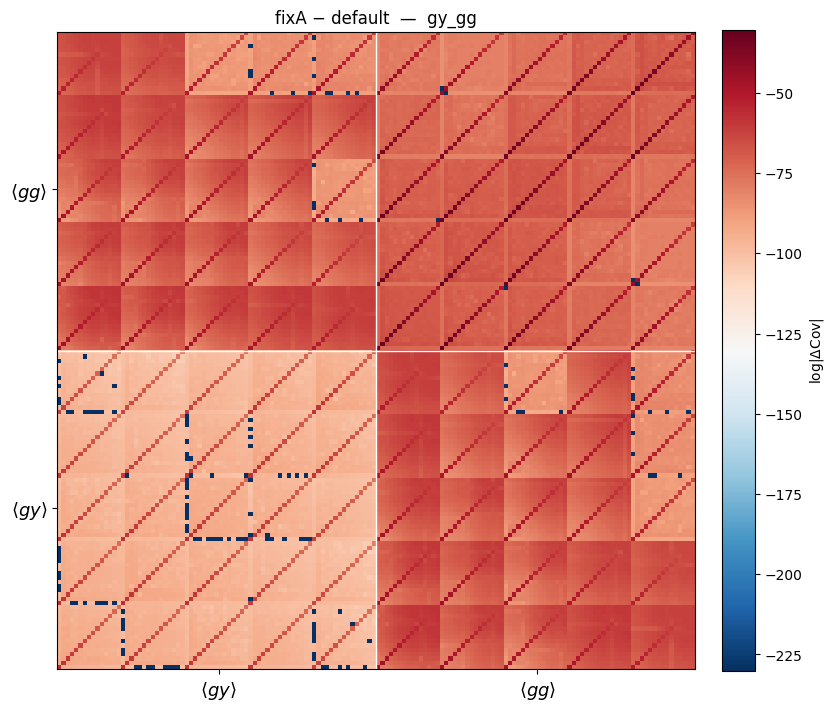


  fixA  —  probes: ['gg']
DV shape : (75,)  (5 bin-combos × 15 ell bins)
  [ 0]  gg  bin_1_1
  [ 1]  gg  bin_2_2
  [ 2]  gg  bin_3_3
  [ 3]  gg  bin_4_4
  [ 4]  gg  bin_5_5

Cov shape       : (75, 75)
Count per probe : {'gg': 5}
Min eigenvalue  : 4.260e-20
N negative eigv : 0


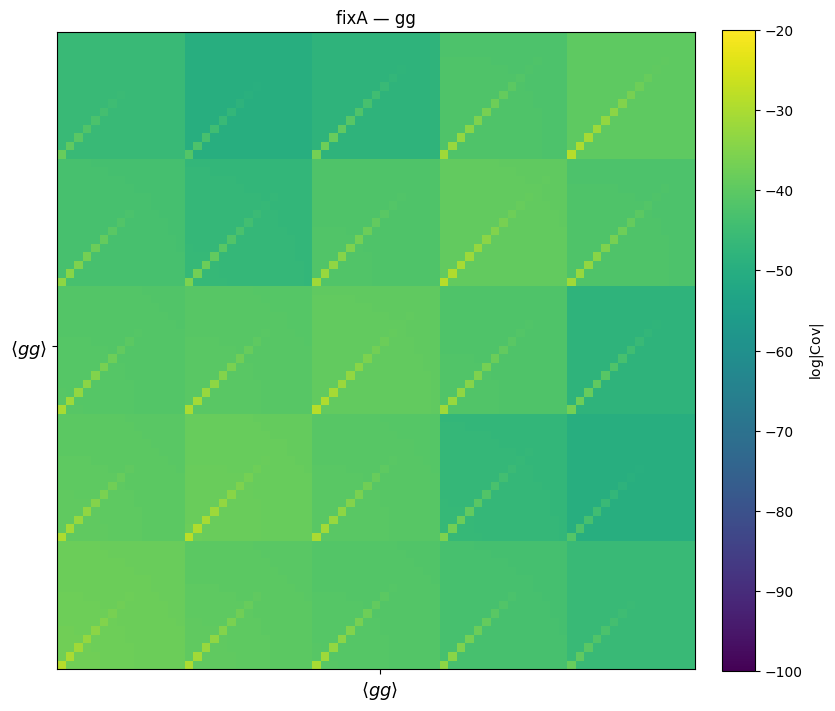

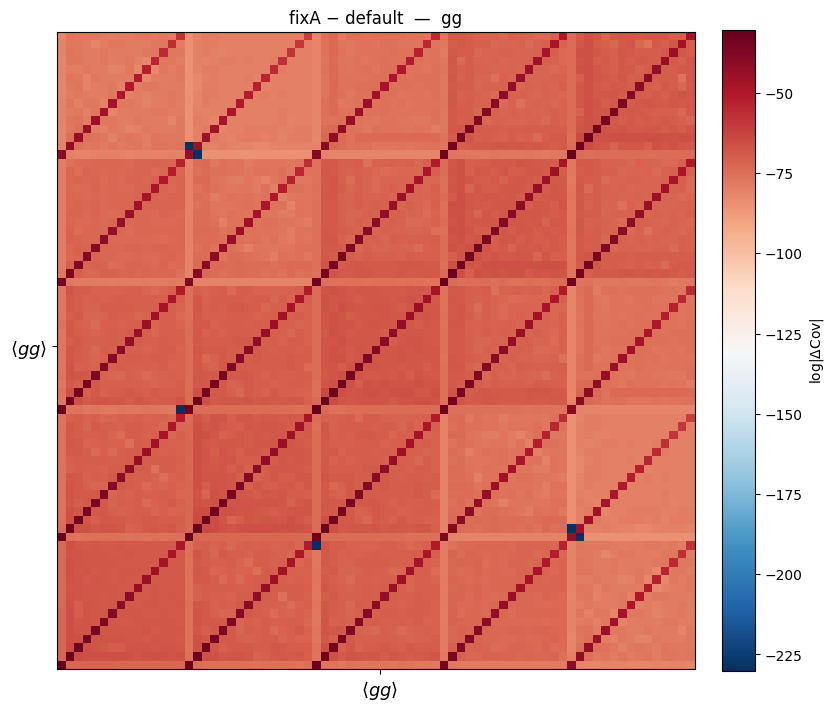

Fix B: mean Cl_gy ratio (fixB / default) = 0.9215  (< 1 because S < 1)
Fix B: mean Cl_yy ratio (fixB / default) = 0.9532  (< 1 because S < 1)
Fix B: get_cov done.

  fixB  —  probes: ['gy', 'gg']
DV shape : (150,)  (10 bin-combos × 15 ell bins)
  [ 0]  gy  bin_1_0
  [ 1]  gy  bin_2_0
  [ 2]  gy  bin_3_0
  [ 3]  gy  bin_4_0
  [ 4]  gy  bin_5_0
  [ 5]  gg  bin_1_1
  [ 6]  gg  bin_2_2
  [ 7]  gg  bin_3_3
  [ 8]  gg  bin_4_4
  [ 9]  gg  bin_5_5

Cov shape       : (150, 150)
Count per probe : {'gy': 5, 'gg': 5}
Min eigenvalue  : -6.768e-27
N negative eigv : 8


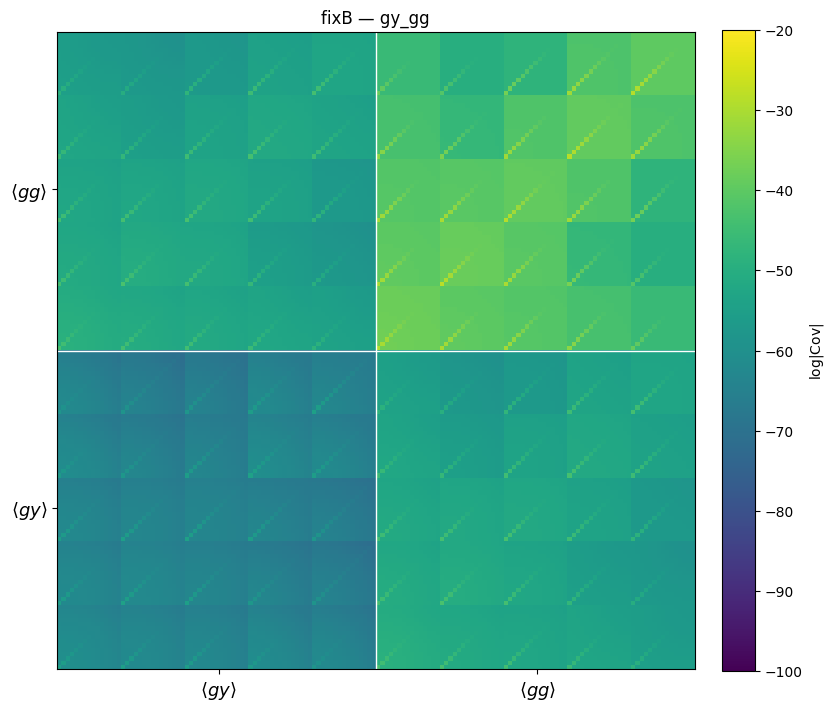

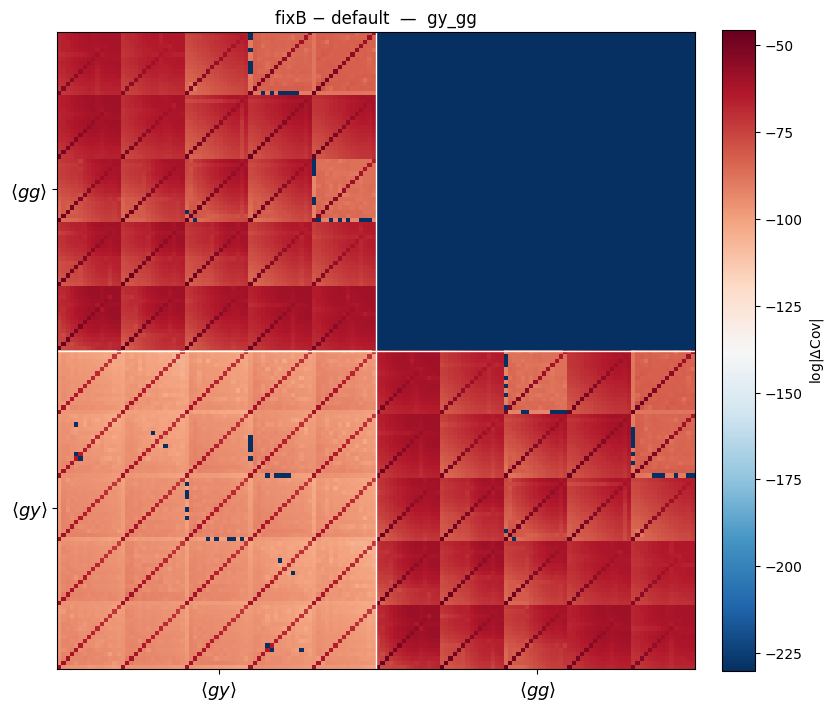


  fixB  —  probes: ['gg']
DV shape : (75,)  (5 bin-combos × 15 ell bins)
  [ 0]  gg  bin_1_1
  [ 1]  gg  bin_2_2
  [ 2]  gg  bin_3_3
  [ 3]  gg  bin_4_4
  [ 4]  gg  bin_5_5

Cov shape       : (75, 75)
Count per probe : {'gg': 5}
Min eigenvalue  : 3.871e-20
N negative eigv : 0


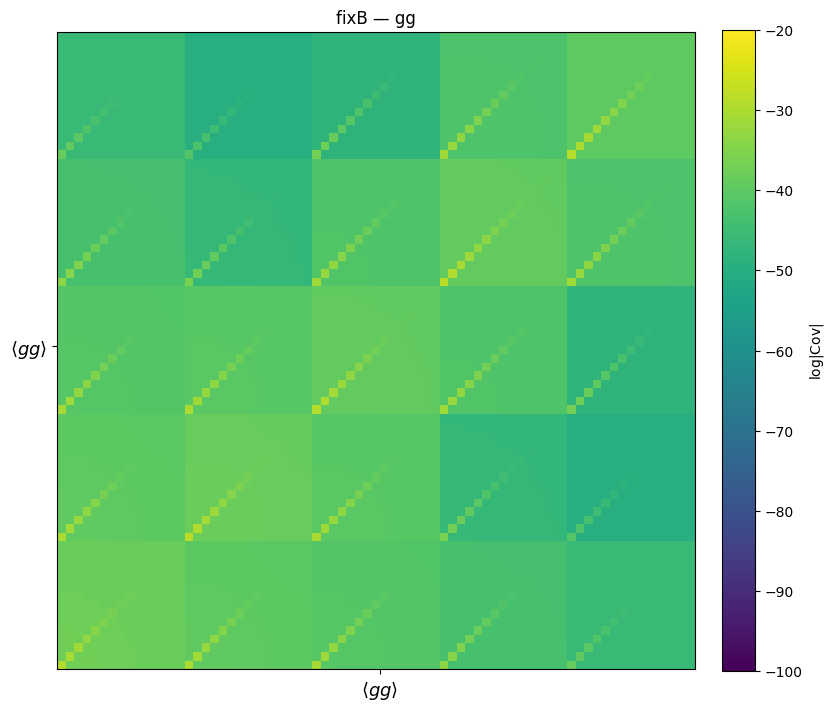

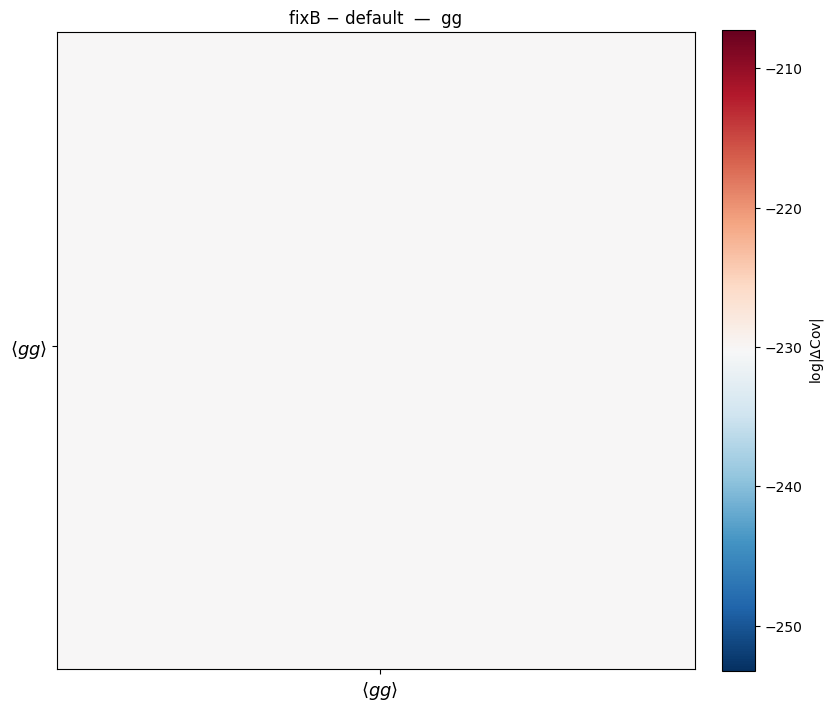

In [19]:
import copy                             
import jax.numpy as jnp
from godmax.base_class import get_vmapped_func_warg                                                                                                         
from godmax.get_covs import get_cov
                                                                                                                                                            
# ── Arrays from the default run ────────────────────────────────────────────────
ell_arr   = np.array(Cls_test.ell_array)           # (nell,)
chi_cls   = np.array(Cls_test.chi_array_for_Cls)   # (nz_for_Cls,)                                                                                          
z_cls_arr = np.array(Cls_test.z_array_for_Cls)     # (nz_for_Cls,)
z_arr     = np.array(Cls_test.z_array)             # (nz,) — 3D P grid                                                                                      
kPk       = np.array(Cls_test.kPk_array)           # (nk,)                                                                                                  
Pmm_sup   = np.array(Cls_test.Pmm_sup_tot_mat)     # (nk, nz)                                                                                               
                                                                                                                                                            
nell_val = len(ell_arr)                                                                                                                                     
nz_cls   = len(z_cls_arr)
log_kPk  = np.log(kPk)                                                                                                                                      
                                            
# Interpolate Pmm_sup from z_array (3D P grid) onto z_array_for_Cls (Limber grid)                                                                           
Pmm_sup_zcls = np.array([               
    np.interp(z_cls_arr, z_arr, Pmm_sup[ik, :])                                                                                                             
    for ik in range(len(kPk))                                                                                                                               
])  # (nk, nz_cls)                                                                                                                                          
                                                                                                                                                            
# Limber k = (ell+0.5)/chi  for every (ell, z_cls) pair
k_lim = (ell_arr[:, None] + 0.5) / np.maximum(chi_cls[None, :], 1.0)  # (nell, nz_cls)                                                                      
                                            
# Evaluate S(k_limber, z) via log-k interpolation at each (ell, z_cls)                                                                                      
S_lz = np.array([
    [np.interp(np.log(k_lim[il, jz]), log_kPk, Pmm_sup_zcls[:, jz])                                                                                         
    for jz in range(nz_cls)]           
    for il in range(nell_val)                                                                                                                               
])  # (nell, nz_cls)                                                                                                                                        
S_lz_jnp = jnp.array(S_lz)              
                                                                                                                                                            
print(f"S_lz shape : {S_lz.shape}  (nell={nell_val}, nz_for_Cls={nz_cls})")                                                                                 
print(f"S_lz range : [{S_lz.min():.4f}, {S_lz.max():.4f}],  mean={S_lz.mean():.4f}")
                                                                                                                                                            

# Cell — helper: DV + Cov + diff plot
                                                                                                                                                            
def _run_dv_cov(cov_obj, probes_arr, label, ref_obj=None):
    """Standard DV + cov block, plus diff vs ref_obj if provided."""                                                                                        
    tag = '_'.join(probes_arr)              
    print(f"\n{'='*62}\n  {label}  —  probes: {probes_arr}\n{'='*62}")
                                                                                                                                                            
    # ── Data vector ────────────────────────────────────────────────                                                                                       
    dv, entries, nell_dv = diag_utils.build_data_vector(                                                                                                    
        cov_obj.Cl_result_dict, probes_arr, key='tot_ellsurvey'                                                                                             
    )                                                                                                                                                       
    print(f"DV shape : {dv.shape}  ({len(entries)} bin-combos × {nell_dv} ell bins)")                                                                       
    for i, (probe, (b1, b2)) in enumerate(entries):                                                                                                         
        print(f"  [{i:2d}]  {probe}  bin_{b1}_{b2}")
                                                                                                                                                            
    # ── Covariance matrix ──────────────────────────────────────────                                                                                       
    cov, _, count_per_probe, nell_c = diag_utils.build_cov_matrix(
        cov_obj.covtot_dict, cov_obj.Cl_result_dict, probes_arr, warn_missing=True                                                                          
    )                                       
    print(f"\nCov shape       : {cov.shape}")                                                                                                               
    print(f"Count per probe : {dict(zip(probes_arr, count_per_probe))}")                                                                                    
    eigvals = np.linalg.eigvalsh(cov)                                                                                                                       
    print(f"Min eigenvalue  : {eigvals.min():.3e}")                                                                                                         
    print(f"N negative eigv : {(eigvals < 0).sum()}")                                                                                                       
                
    # ── Cov plot ───────────────────────────────────────────────────                                                                                       
    fig, ax = plt.subplots(figsize=(9, 9))
    diag_utils.plot_cov_matrix(cov, count_per_probe, probes_arr, nell_c, ax=ax)                                                                             
    ax.set_title(f'{label} — {tag}', fontsize=12)                                                                                                           
    fig.savefig(FIGDIR / f"cov_{label}_{tag}.png", dpi=200, bbox_inches='tight')
    plt.show()                                                                                                                                              
                                                                                                                                                            
    # ── Diff plot vs reference ─────────────────────────────────────                                                                                       
    if ref_obj is not None:                                                                                                                                 
        cov_ref, _, _, _ = diag_utils.build_cov_matrix(                                                                                                     
            ref_obj.covtot_dict, ref_obj.Cl_result_dict, probes_arr, warn_missing=False                                                                     
        )                                   
        diff = cov - cov_ref                                                                                                                                
        bounds = diag_utils.get_probe_boundaries(count_per_probe, nell_c)
                                                                                                                                                            
        fig2, ax2 = plt.subplots(figsize=(9, 9))
        im = ax2.imshow(                                                                                                                                    
            np.log(np.abs(diff) + 1e-100),                                                                                                                  
            origin='lower', cmap='RdBu_r'   
        )                                                                                                                                                   
        for edge in bounds['edges'][1:-1]:
            ax2.axhline(edge - 0.5, color='white', lw=1.0)                                                                                                  
            ax2.axvline(edge - 0.5, color='white', lw=1.0)
        tick_labels = [diag_utils.PROBE_LATEX.get(p, p) for p in probes_arr]                                                                                
        ax2.set_xticks(bounds['centers']); ax2.set_xticklabels(tick_labels, fontsize=13)
        ax2.set_yticks(bounds['centers']); ax2.set_yticklabels(tick_labels, fontsize=13)                                                                    
        ax2.set_xlim(-0.5, cov.shape[1] - 0.5)
        ax2.set_ylim(-0.5, cov.shape[0] - 0.5)                                                                                                              
        plt.colorbar(im, ax=ax2, label=r'$\log|\Delta\mathrm{Cov}|$',
                    fraction=0.046, pad=0.04)                                                                                                              
        ax2.set_title(f'{label} − default  —  {tag}', fontsize=12)                                                                                          
        fig2.savefig(FIGDIR / f"cov_diff_{label}_{tag}.png", dpi=200, bbox_inches='tight')                                                                  
        plt.show()                                                                                                                                          
                
    return cov                                                                                                                                              
                
# Cell — Fix A: patch + get_cov           

# Fix A: Remove Pmm_sup from Pgg                                                                                                                            
# ─────────────────────────────────────────────────────────────────────────────
# cached_power_spectra[2,2] was built from Pgg_tot = Pgg_raw * S.                                                                                           
# Divide by S_lz to recover Pgg_raw on the (nell, nz_for_Cls) Limber grid.
# Only Cl_gal_gal_tot_mat needs recomputing; all other Cls are unchanged.                                                                                   
                                            
cls_fixA = copy.copy(Cls_test)                                                                                                                              
cls_fixA.cached_power_spectra = Cls_test.cached_power_spectra.at[2, 2].set(                                                                                 
    Cls_test.cached_power_spectra[2, 2] / S_lz_jnp                                                                                                          
)                                                                                                                                                           
                                                                                                                                                            
nbins_lens = int(Cls_test.nbins_lens)       
vmapped_gg = get_vmapped_func_warg(cls_fixA.get_Cl_tot, 2, 4)                                                                                               
cls_fixA.Cl_gal_gal_tot_mat = vmapped_gg(
    jnp.arange(nbins_lens), jnp.arange(nbins_lens), 2, 2                                                                                                    
).T  # (nell, nbins_lens, nbins_lens)   
                                                                                                                                                            
ratio_gg = float(                                                                                                                                           
    cls_fixA.Cl_gal_gal_tot_mat.mean() / Cls_test.Cl_gal_gal_tot_mat.mean()
)                                                                                                                                                           
print(f"Fix A: mean Cl_gg ratio (fixA / default) = {ratio_gg:.4f}  (> 1 because S < 1)")
                                                                                                                                                            
cov_fixA = get_cov(                                                                                                                                         
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
    Cl_obj=cls_fixA                                                                                                                                         
)                                       
print("Fix A: get_cov done.")                                                                                                                               
                                                                                                                                                            
# Cell — Fix A: DV + Cov + diff                                                                                                                               
                                                                                                                                                            
for probes_arr in [['gy', 'gg'], ['gg']]:
    _ = _run_dv_cov(cov_fixA, probes_arr, 'fixA', ref_obj=cov_test)                                                                                         
                                            
# Cell — Fix B: patch + get_cov                                                                                                                               
                                                                                                                                                            
# Fix B: Apply Pmm_sup consistently to Pgy and Pyy                                                                                                          
# ─────────────────────────────────────────────────────────────────────────────                                                                             
# The C-S violation might arise because Pgg is suppressed by S but Pgy and Pyy are not:
#   Pgy_raw² > Pgg_raw*S · Pyy_raw  when S < 1
#                                                                                                                                                           
# Applying S to both Pgy and Pyy restores C-S:
#   (Pgy*S)²  ≤  (Pgg*S) · (Pyy*S)  iff  Pgy² ≤ Pgg*Pyy  (natural C-S from physics)                                                                         
#                                                                                                                                                           
# Note: Pky (cached_power_spectra[0,3]) is also updated for consistency                                                                                     
# (similar asymmetric suppression issue exists for the kk/ky/yy sub-block).                                                                                 
# Beam factors are already baked into [2,3] and [3,3]; S multiplies the signal only.                                                                        
                                                                                                                                                            
cls_fixB = copy.copy(Cls_test)                                                                                                                              
                                                                                                                                                            
# Pgy and Pky: multiply by S                                                                                                                                
cls_fixB.cached_power_spectra = (                                                                                                                           
    Cls_test.cached_power_spectra                                                                                                                           
    .at[2, 3].set(Cls_test.cached_power_spectra[2, 3] * S_lz_jnp)                                                                                           
    .at[3, 2].set(Cls_test.cached_power_spectra[2, 3] * S_lz_jnp)  # symmetric
    .at[0, 3].set(Cls_test.cached_power_spectra[0, 3] * S_lz_jnp)                                                                                           
    .at[3, 0].set(Cls_test.cached_power_spectra[0, 3] * S_lz_jnp)  # symmetric
    # Pyy: multiply by S                                                                                                                                    
    .at[3, 3].set(Cls_test.cached_power_spectra[3, 3] * S_lz_jnp)                                                                                           
)                                                                                                                                                           
                                                                                                                                                            
nbins_lens = int(Cls_test.nbins_lens)                                                                                                                       
nbins      = int(Cls_test.nbins)                                                                                                                            
                                                                                                                                                            
# Recompute Cl matrices that depend on probe 3 (y)                                                                                                          
vmapped_gy = get_vmapped_func_warg(cls_fixB.get_Cl_tot, 1, 4)
vmapped_ky = get_vmapped_func_warg(cls_fixB.get_Cl_tot, 1, 4)                                                                                               
                                                                                                                                                            
cls_fixB.Cl_gal_y_tot_mat    = vmapped_gy(jnp.arange(nbins_lens), 0, 2, 3).T  # (nell, nbins_lens)                                                          
cls_fixB.Cl_kappa_y_tot_mat  = vmapped_ky(jnp.arange(nbins),      0, 0, 3).T  # (nell, nbins)                                                               
cls_fixB.Cl_y_y_signal_mat   = cls_fixB.get_Cl_tot(0, 0, 3, 3)                # (nell,)                                                                     
# Preserve the external noise file; only the theory signal changes                                                                                          
cls_fixB.Cl_y_y_tot_mat      = cls_fixB.Cl_y_y_signal_mat + Cls_test.Cl_y_y_noise_mat                                                                       
                                                                                                                                                            
for label, ratio in [                                                                                                                                       
    ('Cl_gy', cls_fixB.Cl_gal_y_tot_mat.mean() / Cls_test.Cl_gal_y_tot_mat.mean()),                                                                         
    ('Cl_yy', cls_fixB.Cl_y_y_signal_mat.mean() / Cls_test.Cl_y_y_signal_mat.mean()),                                                                       
]:                                                                                                                                                          
    print(f"Fix B: mean {label} ratio (fixB / default) = {float(ratio):.4f}  (< 1 because S < 1)")                                                          
                                                                                                                                                            
cov_fixB = get_cov(                                                                                                                                         
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,                                                                                    
    Cl_obj=cls_fixB                                                                                                                                         
)                                       
print("Fix B: get_cov done.")                                                                                                                               
                                                                                                                                                            
# Cell — Fix B: DV + Cov + diff                                                                                                                               
                
for probes_arr in [['gy', 'gg'], ['gg']]:
    _ = _run_dv_cov(cov_fixB, probes_arr, 'fixB', ref_obj=cov_test)
                    

Covariance negative eigenvalue summary
label          min_eigval    n_neg        max_neg
default        -6.813e-27        7     -6.859e-30
fixA           -6.453e-27        6     -6.128e-30
fixB           -6.768e-27        8     -1.927e-30

Worst eigenvector decomposition (default):
  gy bin_1_0  power=0.8947
  gy bin_2_0  power=0.0807
  gy bin_3_0  power=0.0159
  gy bin_4_0  power=0.0077
  gy bin_5_0  power=0.0010
  gg bin_1_1  power=0.0000
  gg bin_2_2  power=0.0000
  gg bin_3_3  power=0.0000
  gg bin_4_4  power=0.0000
  gg bin_5_5  power=0.0000

  Peak ell for dominant entry: ell=717.7


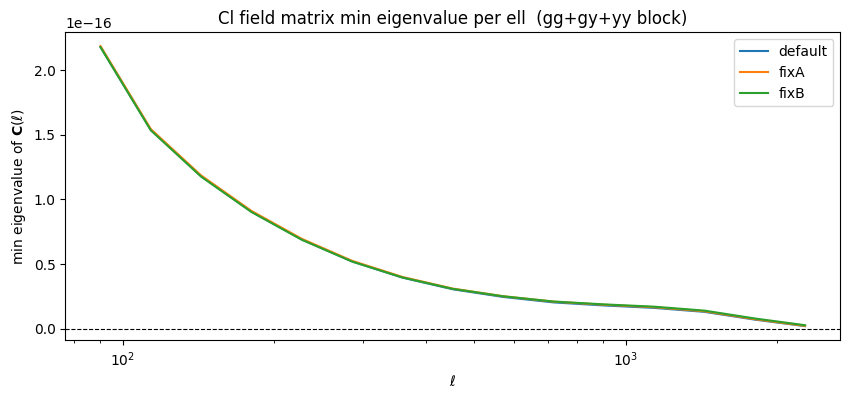

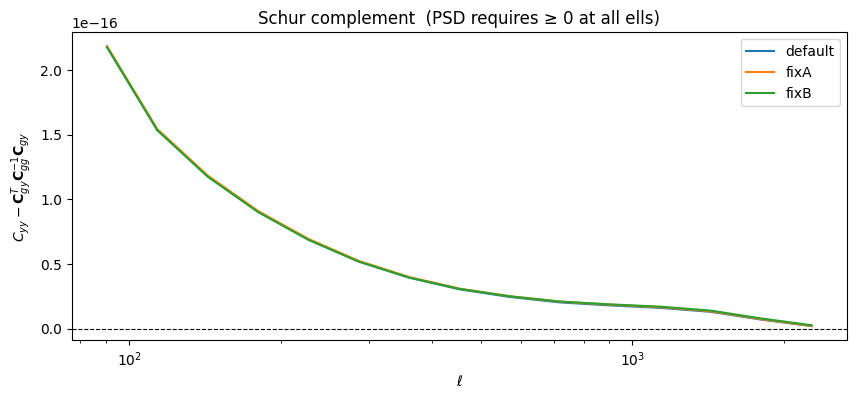

In [20]:
# ── 1. Summary: magnitude of negative eigenvalues across variants ──────────────
print("Covariance negative eigenvalue summary")                                                                                                             
print(f"{'label':<10} {'min_eigval':>14} {'n_neg':>8} {'max_neg':>14}")
for label, cov_obj in [('default', cov_test), ('fixA', cov_fixA), ('fixB', cov_fixB)]:                                                                      
    cov_m, entries, cnt, nell_c = diag_utils.build_cov_matrix(
        cov_obj.covtot_dict, cov_obj.Cl_result_dict, ['gy', 'gg'], warn_missing=False                                                                       
    )
    ev = np.linalg.eigvalsh(cov_m)                                                                                                                          
    neg = ev[ev < 0]                                                                                                                                        
    print(f"{label:<10} {ev.min():>14.3e} {len(neg):>8} {neg.max() if len(neg) else 0.:>14.3e}")
                                                                                                                                                            
# ── 2. Identify the worst eigenvector ─────────────────────────────────────────                                                                            
print("\nWorst eigenvector decomposition (default):")                                                                                                       
cov_m, entries, cnt, nell_c = diag_utils.build_cov_matrix(                                                                                                  
    cov_test.covtot_dict, cov_test.Cl_result_dict, ['gy', 'gg'], warn_missing=False                                                                         
)
eigvals_all, eigvecs_all = np.linalg.eigh(cov_m)                                                                                                            
idx_worst = np.argmin(eigvals_all)                                                                                                                          
v_worst   = eigvecs_all[:, idx_worst]
n_entries = len(entries)                                                                                                                                    
entry_power = np.array([np.sum(v_worst[i*nell_c:(i+1)*nell_c]**2) for i in range(n_entries)])
for i in np.argsort(entry_power)[::-1]:                                                                                                                     
    probe, (b1, b2) = entries[i]
    print(f"  {probe} bin_{b1}_{b2}  power={entry_power[i]:.4f}")                                                                                           

# Which ell within the dominant entry?                                                                                                                      
dom = np.argmax(entry_power)
ell_power = v_worst[dom*nell_c:(dom+1)*nell_c]**2                                                                                                           
ell_survey = np.array(cov_test.Cl_result_dict['l_array_survey'])                                                                                            
print(f"\n  Peak ell for dominant entry: ell={ell_survey[np.argmax(ell_power)]:.1f}")                                                                       
                                                                                                                                                            
# ── 3. Per-ell Cl field matrix PSD check ──────────────────────────────────────                                                                            
nbins_lens = int(cov_test.nbins_lens)                                                                                                                       
                                                                                                                                                            
fig, ax = plt.subplots(figsize=(10, 4))                                                                                                                     
for label, cov_obj in [('default', cov_test), ('fixA', cov_fixA), ('fixB', cov_fixB)]:                                                                      
    min_ev_ell = []                                                                                                                                         
    for il in range(len(ell_survey)):
        dim = nbins_lens + 1                                                                                                                                
        Cf = np.zeros((dim, dim))
        for jb1 in range(nbins_lens):                                                                                                                       
            for jb2 in range(nbins_lens):
                Cf[jb1, jb2] = float(                                                                                                                       
                    cov_obj.Cl_result_dict['gg'][f'bin_{jb1+1}_{jb2+1}']['tot_plus_noise_ellsurvey'][il]
                )                                                                                                                                           
        for jb1 in range(nbins_lens):
            v = float(cov_obj.Cl_result_dict['gy'][f'bin_{jb1+1}_0']['tot_ellsurvey'][il])                                                                  
            Cf[jb1, nbins_lens] = v                                                                                                                         
            Cf[nbins_lens, jb1] = v
        Cf[nbins_lens, nbins_lens] = float(                                                                                                                 
            cov_obj.Cl_result_dict['yy']['bin_0_0']['tot_plus_noise_ellsurvey'][il]                                                                         
        )
        min_ev_ell.append(np.linalg.eigvalsh(Cf).min())                                                                                                     
    min_ev_ell = np.array(min_ev_ell)                                                                                                                       
    ax.semilogx(ell_survey, min_ev_ell, label=label)
                                                                                                                                                            
ax.axhline(0, color='k', lw=0.8, ls='--')                                                                                                                   
ax.set(xlabel=r'$\ell$', ylabel=r'min eigenvalue of $\mathbf{C}(\ell)$',
        title='Cl field matrix min eigenvalue per ell  (gg+gy+yy block)')                                                                                    
ax.legend()                                                                                                                                                 
fig.savefig(FIGDIR / 'diag_field_matrix_eigval.png', dpi=200, bbox_inches='tight')                                                                          
plt.show()                                                                                                                                                  

# ── 4. Per-ell Schur complement: C_yy - C_gy^T C_gg^{-1} C_gy ────────────────                                                                             
fig2, ax2 = plt.subplots(figsize=(10, 4))
for label, cov_obj in [('default', cov_test), ('fixA', cov_fixA), ('fixB', cov_fixB)]:                                                                      
    schur_ell = []                                                                                                                                          
    for il in range(len(ell_survey)):
        Cgg = np.array([                                                                                                                                    
            [float(cov_obj.Cl_result_dict['gg'][f'bin_{jb1+1}_{jb2+1}']['tot_plus_noise_ellsurvey'][il])                                                    
            for jb2 in range(nbins_lens)]                                                                                                                  
            for jb1 in range(nbins_lens)                                                                                                                    
        ])                                                                                                                                                  
        Cgy = np.array([
            float(cov_obj.Cl_result_dict['gy'][f'bin_{jb1+1}_0']['tot_ellsurvey'][il])
            for jb1 in range(nbins_lens)                                                                                                                    
        ])
        Cyy = float(cov_obj.Cl_result_dict['yy']['bin_0_0']['tot_plus_noise_ellsurvey'][il])                                                                
        try:                                                                                                                                                
            schur = Cyy - Cgy @ np.linalg.solve(Cgg, Cgy)
        except np.linalg.LinAlgError:                                                                                                                       
            schur = np.nan
        schur_ell.append(schur)                                                                                                                             
    ax2.semilogx(ell_survey, schur_ell, label=label)
                                                                                                                                                            
ax2.axhline(0, color='k', lw=0.8, ls='--')                                                                                                                  
ax2.set(xlabel=r'$\ell$', ylabel=r'$C_{yy} - \mathbf{C}_{gy}^T \mathbf{C}_{gg}^{-1} \mathbf{C}_{gy}$',
        title='Schur complement  (PSD requires ≥ 0 at all ells)')                                                                                           
ax2.legend()                                                                                                                                                
fig2.savefig(FIGDIR / 'diag_schur_complement.png', dpi=200, bbox_inches='tight')                                                                            
plt.show()   

Knox formula vs cov_test.covG_dict — diagonal relative errors
probe pair    bin combo                  max_rel_err   mean_rel_err  status
----------------------------------------------------------------------------
ky_ky         bin_1_0_1_0                  2.112e-16      7.404e-17  OK
ky_ky         bin_1_0_2_0                  1.976e-16      7.252e-17  OK
ky_ky         bin_1_0_3_0                  2.024e-16      5.092e-17  OK
ky_ky         bin_1_0_4_0                  2.186e-16      3.760e-17  OK
ky_ky         bin_1_0_5_0                  1.612e-16      2.673e-17  OK
ky_ky         bin_2_0_1_0                  1.976e-16      7.252e-17  OK
ky_ky         bin_2_0_2_0                  2.049e-16      5.818e-17  OK
ky_ky         bin_2_0_3_0                  2.130e-16      3.239e-17  OK
ky_ky         bin_2_0_4_0                  1.527e-16      5.515e-17  OK
ky_ky         bin_2_0_5_0                  1.583e-16      1.804e-17  OK
ky_ky         bin_3_0_1_0                  2.024e-16      5.092e-

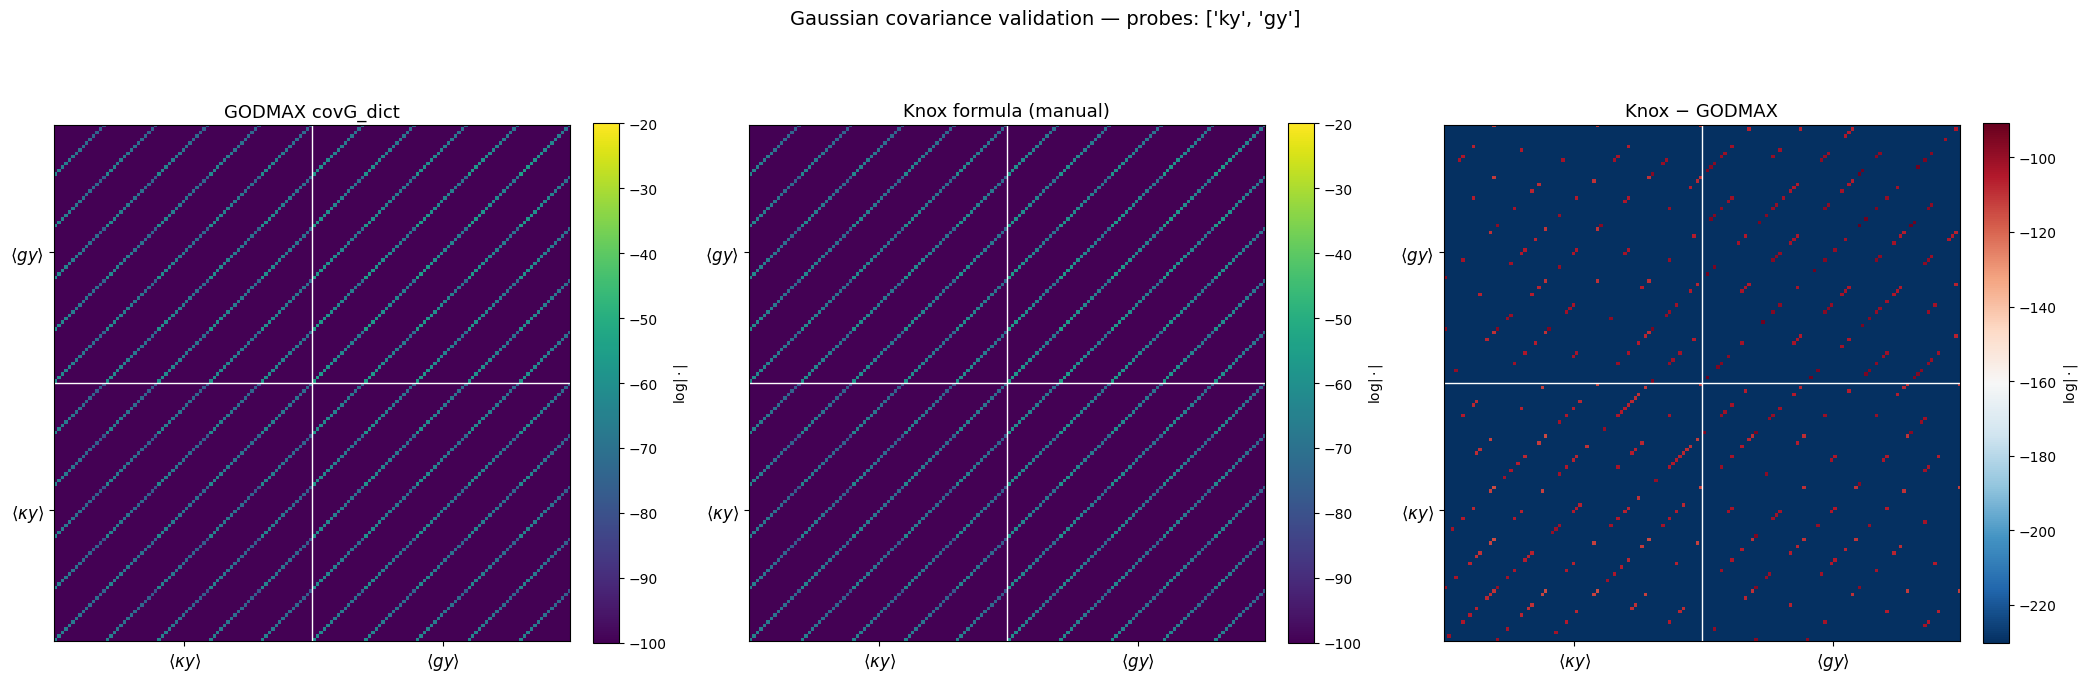

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Knox formula validation: manual vs cov_test.covG_dict
# ══════════════════════════════════════════════════════════════════════════════

# ── 0. Helpers ────────────────────────────────────────────────────────────────

def _cl_tot_noise(Cl_result_dict, probe, ba, bb):
    """
    Return Cl^{tot+N}_{probe, ba, bb} as (nell,) array.
    Tries: (probe,ba,bb), (probe,bb,ba),
           (rev_probe,bb,ba), (rev_probe,ba,bb).
    Reversed-probe + reversed-bins is tried BEFORE reversed-probe + same-bins
    so that e.g. Cl_kg(b1,b3) → Cl_gk(b3,b1), not Cl_gk(b1,b3).
    Returns zeros if not found.
    """
    ell = np.array(Cl_result_dict["l_array_survey"])
    for p, a, b in [(probe, ba, bb), (probe, bb, ba),
                    (probe[::-1], bb, ba),   # reversed bins FIRST for reversed probe
                    (probe[::-1], ba, bb)]:
        if p not in Cl_result_dict:
            continue
        bkey = f"bin_{a}_{b}"
        entry = Cl_result_dict[p].get(bkey, {})
        if "tot_plus_noise_ellsurvey" in entry:
            return np.array(entry["tot_plus_noise_ellsurvey"])
    return np.zeros_like(ell, dtype=float)


def _cl_noise_only(Cl_result_dict, probe, ba, bb):
    """
    Return Nl_{probe, ba, bb} = Cl_tot_noise - Cl_signal as (nell,) array.
    Same lookup ordering as _cl_tot_noise.  Returns zeros if not found.
    """
    ell = np.array(Cl_result_dict["l_array_survey"])
    for p, a, b in [(probe, ba, bb), (probe, bb, ba),
                    (probe[::-1], bb, ba),
                    (probe[::-1], ba, bb)]:
        if p not in Cl_result_dict:
            continue
        bkey = f"bin_{a}_{b}"
        entry = Cl_result_dict[p].get(bkey, {})
        if "tot_plus_noise_ellsurvey" in entry and "tot_ellsurvey" in entry:
            return (np.array(entry["tot_plus_noise_ellsurvey"])
                    - np.array(entry["tot_ellsurvey"]))
    return np.zeros_like(ell, dtype=float)


def knox_diag(Cl_result_dict, stat1, stat2, b1, b2, b3, b4, fsky_dict):
    """
    Knox-formula Gaussian covariance diagonal (nell,) for a single block.

    Cov_G(Cl^{AB}_{b1b2}_ℓ, Cl^{CD}_{b3b4}_ℓ) =
        [C̃^{AC}_{b1b3} · C̃^{BD}_{b2b4} + C̃^{AD}_{b1b4} · C̃^{BC}_{b2b3}
         + Nl_BB (kk×kk only)]
        / [fsky · (2ℓ+1) · Δℓ]

    where A,B = stat1; C,D = stat2; C̃ = tot+noise.
    Nl_BB matches the GODMAX get_cov_G B-mode shape-noise correction:
        Nl_BB = δ_{b1b3}δ_{b2b4} Nl^{AC}·Nl^{BD}
              + δ_{b1b4}δ_{b2b3} Nl^{AD}·Nl^{BC}
    """
    A, B = stat1[0], stat1[1]
    C, D = stat2[0], stat2[1]

    ell  = np.array(Cl_result_dict["l_array_survey"])
    dl   = np.array(Cl_result_dict["dl_array_survey"])
    fsky = np.sqrt(fsky_dict.get(A+B, fsky_dict.get(B+A, 0.1)) *
                   fsky_dict.get(C+D, fsky_dict.get(D+C, 0.1)))

    Cl_AC = _cl_tot_noise(Cl_result_dict, A+C, b1, b3)
    Cl_BD = _cl_tot_noise(Cl_result_dict, B+D, b2, b4)
    Cl_AD = _cl_tot_noise(Cl_result_dict, A+D, b1, b4)
    Cl_BC = _cl_tot_noise(Cl_result_dict, B+C, b2, b3)

    numerator = Cl_AC * Cl_BD + Cl_AD * Cl_BC

    # B-mode shape-noise correction (mirrors GODMAX get_cov_G iskk branch)
    if stat1 == "kk" and stat2 == "kk":
        Nl_AC = _cl_noise_only(Cl_result_dict, A+C, b1, b3)
        Nl_BD = _cl_noise_only(Cl_result_dict, B+D, b2, b4)
        Nl_AD = _cl_noise_only(Cl_result_dict, A+D, b1, b4)
        Nl_BC = _cl_noise_only(Cl_result_dict, B+C, b2, b3)
        Nl_BB = (int(b1 == b3) * int(b2 == b4) * Nl_AC * Nl_BD
               + int(b1 == b4) * int(b2 == b3) * Nl_AD * Nl_BC)
        numerator = numerator + Nl_BB

    return numerator / (fsky * (2*ell + 1) * dl)


def build_knox_cov_matrix(Cl_result_dict, probes_arr, fsky_dict, bin_selection=None):
    """
    Build the full Gaussian covariance matrix for probes_arr from scratch
    using the Knox formula — no covtot_dict required.

    Returns (cov, entries, count_per_probe, nell) — same signature as
    diag_utils.build_cov_matrix.
    """
    entries, count_per_probe = diag_utils.get_data_vector_entries(
        Cl_result_dict, probes_arr, bin_selection
    )
    nell = len(Cl_result_dict["l_array_survey"])
    n    = len(entries)
    cov  = np.zeros((n * nell, n * nell))

    for jp1, (stat1, (b1, b2)) in enumerate(entries):
        for jp2, (stat2, (b3, b4)) in enumerate(entries):
            d = knox_diag(Cl_result_dict, stat1, stat2, b1, b2, b3, b4, fsky_dict)
            cov[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = np.diag(d)

    upper = np.triu(cov)
    cov   = upper + upper.T - np.diag(np.diag(cov))
    return cov, entries, count_per_probe, nell


# ── 1. Block-level comparison: Knox diagonal vs covG_dict diagonal ────────────
print("Knox formula vs cov_test.covG_dict — diagonal relative errors")
print(f"{'probe pair':<12}  {'bin combo':<24}  {'max_rel_err':>12}  {'mean_rel_err':>13}  {'status'}")
print("-" * 76)

all_ok = True
for stat12_key, blocks in cov_test.covG_dict.items():
    stat1, stat2 = stat12_key.split("_")
    bin_keys = sorted(k for k in blocks if k.startswith("bin_"))
    for bkey in bin_keys:
        b1, b2, b3, b4 = [int(x) for x in bkey.split("_")[1:]]

        # GODMAX Gaussian diagonal
        godmax_diag = np.diag(np.array(blocks[bkey]))          # (nell,)

        # Knox formula diagonal (independent implementation)
        knox_d = knox_diag(
            cov_test.Cl_result_dict, stat1, stat2, b1, b2, b3, b4, cov_test.fsky_dict
        )

        denom    = np.maximum(np.abs(godmax_diag), 1e-100)
        rel_err  = np.abs(knox_d - godmax_diag) / denom
        status   = "OK" if rel_err.max() < 1e-10 else "MISMATCH"
        if status != "OK":
            all_ok = False

        print(f"{stat12_key:<12}  {bkey:<24}  {rel_err.max():>12.3e}  "
              f"{rel_err.mean():>13.3e}  {status}")

print()
print(f"Overall: {'ALL BLOCKS AGREE to floating-point precision' if all_ok else 'MISMATCHES FOUND'}")


# ── 2. Assembled matrix comparison for a probe list ───────────────────────────
probes_arr = ["ky", "gy"]       # ← change to any probe list

# GODMAX Gaussian-only (from covG_dict)
cov_G_godmax, entries_g, cnt_g, nell_g = diag_utils.build_cov_matrix(
    cov_test.covG_dict, cov_test.Cl_result_dict, probes_arr, warn_missing=False
)

# Independent Knox assembly
cov_G_knox, entries_k, cnt_k, nell_k = build_knox_cov_matrix(
    cov_test.Cl_result_dict, probes_arr, cov_test.fsky_dict
)

diff      = cov_G_knox - cov_G_godmax
rel_diff  = np.abs(diff) / np.maximum(np.abs(cov_G_godmax), 1e-100)

print(f"\nAssembled Gaussian cov  —  probes: {probes_arr}")
print(f"  Shape                 : {cov_G_godmax.shape}")
print(f"  Max |ΔCov|/|Cov_G|   : {rel_diff.max():.3e}")
print(f"  Mean |ΔCov|/|Cov_G|  : {rel_diff.mean():.3e}")
print(f"  Max |ΔCov|            : {np.abs(diff).max():.3e}")

ev_godmax = np.linalg.eigvalsh(cov_G_godmax)
ev_knox   = np.linalg.eigvalsh(cov_G_knox)

print(f"  Min eigval GODMAX     : {ev_godmax.min():.3e}")
print(f"  Max eigval GODMAX     : {ev_godmax.max():.3e}")
print(f"  Min eigval Knox       : {ev_knox.min():.3e}")
print(f"  Max eigval Knox       : {ev_knox.max():.3e}")

# Full eigenvalue table
print(f"\nAll eigenvalues — GODMAX covG_dict vs Knox   (probes: {probes_arr})")
print(f"{'idx':>5}  {'GODMAX':>18}  {'Knox':>18}  {'rel_diff':>12}")
print("-" * 60)
for i, (eg, ek) in enumerate(zip(ev_godmax, ev_knox)):
    rdiff = abs(eg - ek) / max(abs(eg), abs(ek), 1e-100)
    flag  = "  *** NEG" if (eg < 0 or ek < 0) else ""
    print(f"{i:>5}  {eg:>18.6e}  {ek:>18.6e}  {rdiff:>12.3e}{flag}")

print()
print(f"GODMAX  min={ev_godmax.min():.3e}  max={ev_godmax.max():.3e}  "
      f"n_neg={(ev_godmax < 0).sum()}")
print(f"Knox    min={ev_knox.min():.3e}  max={ev_knox.max():.3e}  "
      f"n_neg={(ev_knox < 0).sum()}")
cnum_g = ev_godmax.max() / max(abs(ev_godmax.min()), 1e-100)
cnum_k = ev_knox.max()   / max(abs(ev_knox.min()),   1e-100)
print(f"Condition number GODMAX : {cnum_g:.3e}")
print(f"Condition number Knox   : {cnum_k:.3e}")


# ── 3. Plot: GODMAX G-cov  |  Knox G-cov  |  diff ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, mat, title in zip(
    axes,
    [cov_G_godmax,  cov_G_knox,    diff],
    ["GODMAX covG_dict", "Knox formula (manual)", "Knox − GODMAX"]
):
    bounds = diag_utils.get_probe_boundaries(cnt_g, nell_g)
    im = ax.imshow(
        np.log(np.abs(mat) + 1e-100),
        origin="lower",
        cmap="RdBu_r" if "Knox −" in title else "viridis",
        vmin=(None if "Knox −" in title else -100),
        vmax=(None if "Knox −" in title else -20),
    )
    for edge in bounds["edges"][1:-1]:
        ax.axhline(edge - 0.5, color="white", lw=1.0)
        ax.axvline(edge - 0.5, color="white", lw=1.0)
    tick_labels = [diag_utils.PROBE_LATEX.get(p, p) for p in probes_arr]
    ax.set_xticks(bounds["centers"]); ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_yticks(bounds["centers"]); ax.set_yticklabels(tick_labels, fontsize=12)
    ax.set_xlim(-0.5, mat.shape[1] - 0.5)
    ax.set_ylim(-0.5, mat.shape[0] - 0.5)
    plt.colorbar(im, ax=ax, label=r"$\log|\cdot|$", fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)

fig.suptitle(
    f"Gaussian covariance validation — probes: {probes_arr}",
    fontsize=14, y=1.01
)
fig.tight_layout()
fig.savefig(FIGDIR / f"cov_G_knox_validation_{'_'.join(probes_arr)}.png",
            dpi=200, bbox_inches="tight")
plt.show()



Assembled Gaussian cov  —  probes: ['gy', 'gg']
  Shape                 : (150, 150)
  Max |ΔCov|/|Cov_G|   : 2.198e-16
  Mean |ΔCov|/|Cov_G|  : 2.956e-18
  Max |ΔCov|            : 5.049e-29
  Min eigval GODMAX     : -1.528e-29
  Max eigval GODMAX     : 5.216e-13
  Min eigval Knox       : -3.221e-29
  Max eigval Knox       : 5.216e-13

All eigenvalues — GODMAX covG_dict vs Knox   (probes: ['gy', 'gg'])
  idx              GODMAX                Knox      rel_diff
------------------------------------------------------------
    0       -1.528033e-29       -3.220552e-29     5.255e-01  *** NEG
    1       -5.445045e-30       -1.729160e-29     6.851e-01  *** NEG
    2        2.768185e-31       -1.092640e-30     1.253e+00  *** NEG
    3        5.107288e-31        1.784427e-31     6.506e-01
    4        6.411966e-31        5.088186e-31     2.065e-01
    5        1.159957e-30        6.315635e-31     4.555e-01
    6        2.171665e-30        1.167033e-30     4.626e-01
    7        2.445827e-30

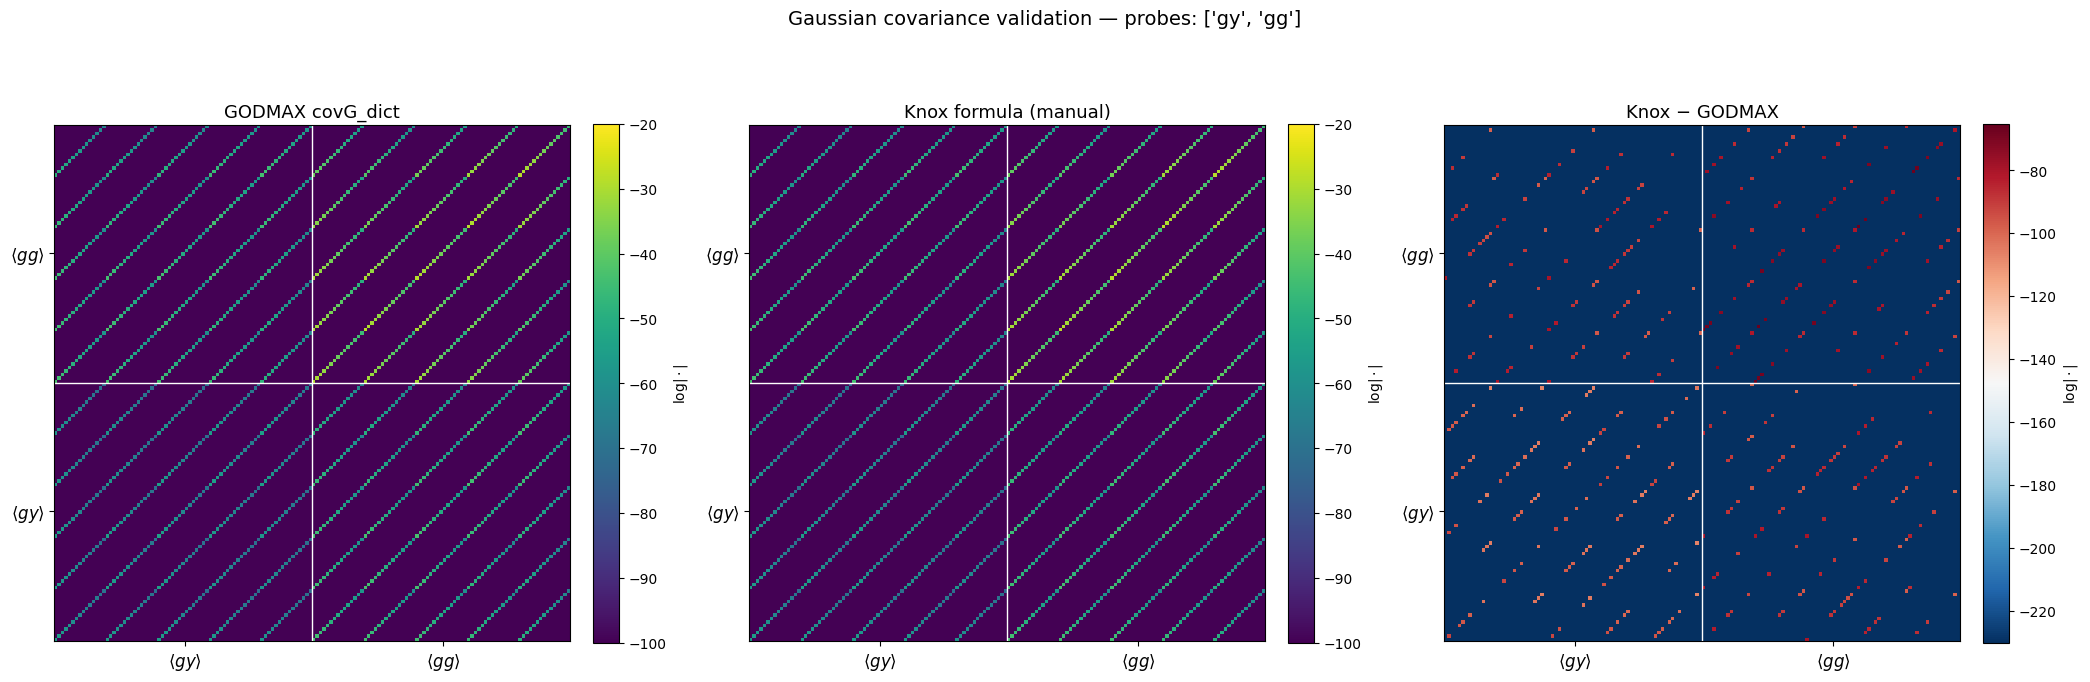

In [25]:
# ── 2. Assembled matrix comparison for a probe list ───────────────────────────
probes_arr = ["gy", "gg"]       # ← change to any probe list

# GODMAX Gaussian-only (from covG_dict)
cov_G_godmax, entries_g, cnt_g, nell_g = diag_utils.build_cov_matrix(
    cov_test.covG_dict, cov_test.Cl_result_dict, probes_arr, warn_missing=False
)

# Independent Knox assembly
cov_G_knox, entries_k, cnt_k, nell_k = build_knox_cov_matrix(
    cov_test.Cl_result_dict, probes_arr, cov_test.fsky_dict
)

diff      = cov_G_knox - cov_G_godmax
rel_diff  = np.abs(diff) / np.maximum(np.abs(cov_G_godmax), 1e-100)

print(f"\nAssembled Gaussian cov  —  probes: {probes_arr}")
print(f"  Shape                 : {cov_G_godmax.shape}")
print(f"  Max |ΔCov|/|Cov_G|   : {rel_diff.max():.3e}")
print(f"  Mean |ΔCov|/|Cov_G|  : {rel_diff.mean():.3e}")
print(f"  Max |ΔCov|            : {np.abs(diff).max():.3e}")

ev_godmax = np.linalg.eigvalsh(cov_G_godmax)
ev_knox   = np.linalg.eigvalsh(cov_G_knox)

print(f"  Min eigval GODMAX     : {ev_godmax.min():.3e}")
print(f"  Max eigval GODMAX     : {ev_godmax.max():.3e}")
print(f"  Min eigval Knox       : {ev_knox.min():.3e}")
print(f"  Max eigval Knox       : {ev_knox.max():.3e}")

# Full eigenvalue table
print(f"\nAll eigenvalues — GODMAX covG_dict vs Knox   (probes: {probes_arr})")
print(f"{'idx':>5}  {'GODMAX':>18}  {'Knox':>18}  {'rel_diff':>12}")
print("-" * 60)
for i, (eg, ek) in enumerate(zip(ev_godmax, ev_knox)):
    rdiff = abs(eg - ek) / max(abs(eg), abs(ek), 1e-100)
    flag  = "  *** NEG" if (eg < 0 or ek < 0) else ""
    print(f"{i:>5}  {eg:>18.6e}  {ek:>18.6e}  {rdiff:>12.3e}{flag}")

print()
print(f"GODMAX  min={ev_godmax.min():.3e}  max={ev_godmax.max():.3e}  "
      f"n_neg={(ev_godmax < 0).sum()}")
print(f"Knox    min={ev_knox.min():.3e}  max={ev_knox.max():.3e}  "
      f"n_neg={(ev_knox < 0).sum()}")
cnum_g = ev_godmax.max() / max(abs(ev_godmax.min()), 1e-100)
cnum_k = ev_knox.max()   / max(abs(ev_knox.min()),   1e-100)
print(f"Condition number GODMAX : {cnum_g:.3e}")
print(f"Condition number Knox   : {cnum_k:.3e}")


# ── 3. Plot: GODMAX G-cov  |  Knox G-cov  |  diff ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, mat, title in zip(
    axes,
    [cov_G_godmax,  cov_G_knox,    diff],
    ["GODMAX covG_dict", "Knox formula (manual)", "Knox − GODMAX"]
):
    bounds = diag_utils.get_probe_boundaries(cnt_g, nell_g)
    im = ax.imshow(
        np.log(np.abs(mat) + 1e-100),
        origin="lower",
        cmap="RdBu_r" if "Knox −" in title else "viridis",
        vmin=(None if "Knox −" in title else -100),
        vmax=(None if "Knox −" in title else -20),
    )
    for edge in bounds["edges"][1:-1]:
        ax.axhline(edge - 0.5, color="white", lw=1.0)
        ax.axvline(edge - 0.5, color="white", lw=1.0)
    tick_labels = [diag_utils.PROBE_LATEX.get(p, p) for p in probes_arr]
    ax.set_xticks(bounds["centers"]); ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_yticks(bounds["centers"]); ax.set_yticklabels(tick_labels, fontsize=12)
    ax.set_xlim(-0.5, mat.shape[1] - 0.5)
    ax.set_ylim(-0.5, mat.shape[0] - 0.5)
    plt.colorbar(im, ax=ax, label=r"$\log|\cdot|$", fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)

fig.suptitle(
    f"Gaussian covariance validation — probes: {probes_arr}",
    fontsize=14, y=1.01
)
fig.tight_layout()
fig.savefig(FIGDIR / f"cov_G_knox_validation_{'_'.join(probes_arr)}.png",
            dpi=200, bbox_inches="tight")
plt.show()


## Testing if clipping actually physically changes the covariance by a huge factor

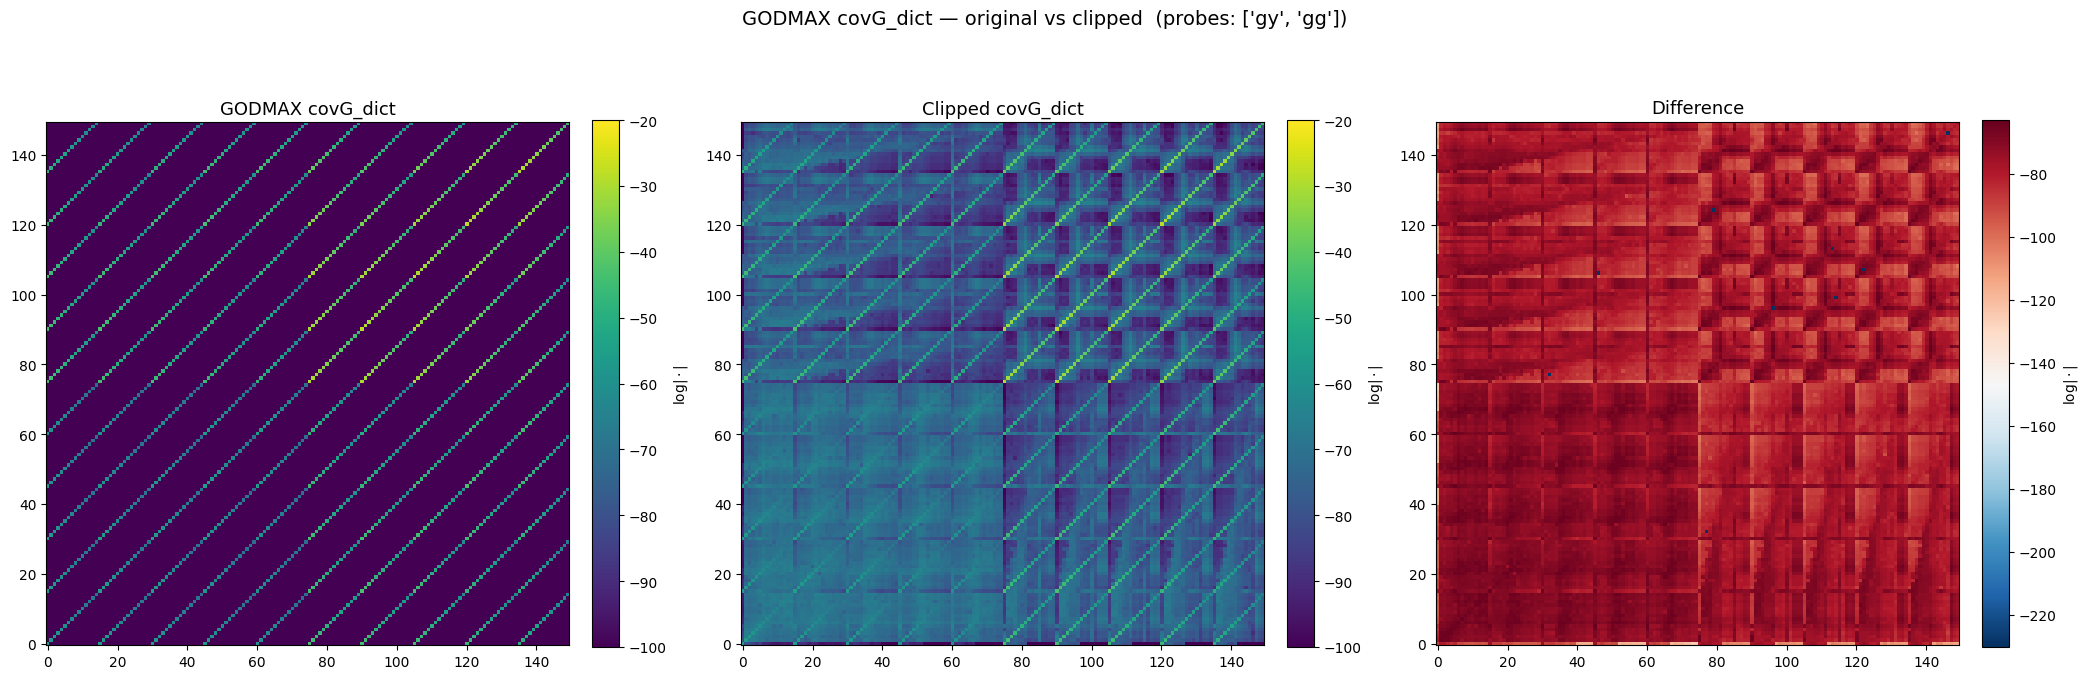

In [27]:
eigvals, eigvecs = np.linalg.eigh(cov_G_godmax)

if np.any(eigvals < 0):
    n_neg = np.sum(eigvals < 0)
    frac = np.abs(eigvals[eigvals < 0]).max() / eigvals.max()
    print(
        f"WARNING: GODMAX covG_dict has {n_neg} negative eigenvalues "
        f"(max |neg| / max eigval = {frac:.3e})"
    )
    eigvals = np.maximum(eigvals, 0.0)

covtot_clipped = eigvecs @ np.diag(eigvals) @ eigvecs.T
diff = covtot_clipped - cov_G_godmax

# plot the covariance matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

mats = [cov_G_godmax, covtot_clipped, diff]
titles = ["GODMAX covG_dict", "Clipped covG_dict", "Difference"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(
        np.log(np.abs(mat) + 1e-100),
        origin="lower",
        cmap="RdBu_r" if "Difference" in title else "viridis",
        vmin=(None if "Difference" in title else -100),
        vmax=(None if "Difference" in title else -20),
    )
    plt.colorbar(im, ax=ax, label=r"$\log|\cdot|$", fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)

fig.suptitle(
    f"GODMAX covG_dict — original vs clipped  (probes: {probes_arr})",
    fontsize=14, y=1.01
)
fig.tight_layout()
fig.savefig(
    FIGDIR / f"cov_G_godmax_clipped_comparison_{'_'.join(probes_arr)}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

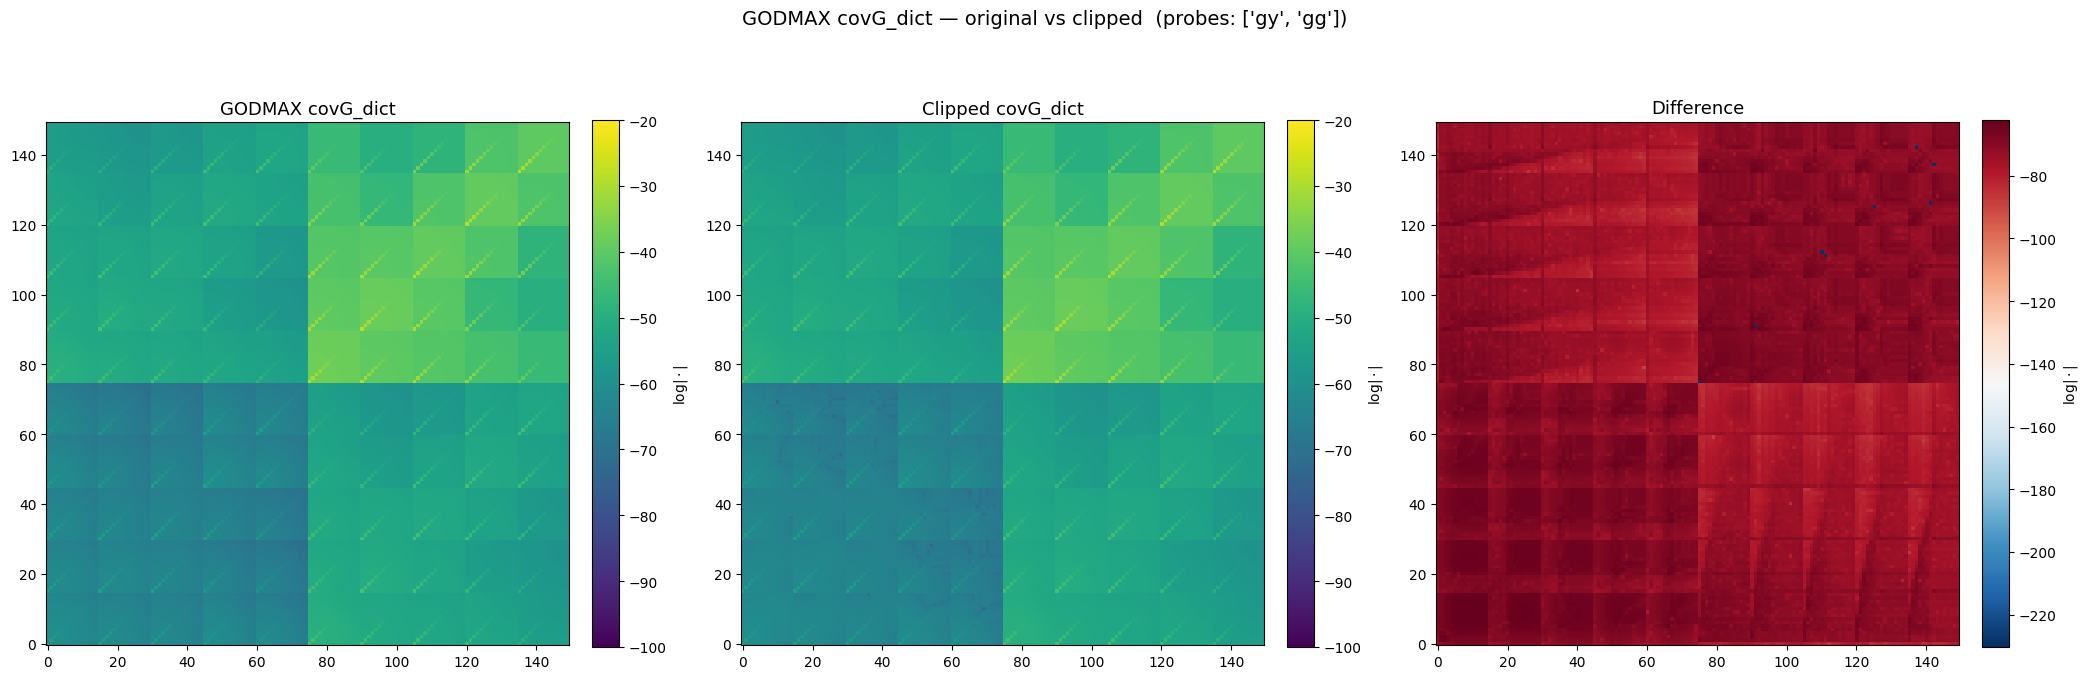

In [28]:
probes_arr = ['gy','gg']          
                                                                                                                                                            
# ── Data vector ───────────────────────────────────────────────────────────────                                                                            
dv, entries, nell = diag_utils.build_data_vector(                                                                                                           
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    key='tot_ellsurvey',       # 'tot_plus_noise_ellsurvey' for signal+noise                                                                                
)                                                                                                                                                           

cov, entries, count_per_probe, nell = diag_utils.build_cov_matrix(                                                                                          
    cov_test.covtot_dict,                                                                                                                                   
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    warn_missing=True,                                                                                                                                      
) 

eigvals, eigvecs = np.linalg.eigh(cov)

if np.any(eigvals < 0):
    n_neg = np.sum(eigvals < 0)
    frac = np.abs(eigvals[eigvals < 0]).max() / eigvals.max()
    print(
        f"WARNING: GODMAX covG_dict has {n_neg} negative eigenvalues "
        f"(max |neg| / max eigval = {frac:.3e})"
    )
    eigvals = np.maximum(eigvals, 0.0)

covtot_clipped = eigvecs @ np.diag(eigvals) @ eigvecs.T
diff = covtot_clipped - cov

# plot the covariance matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

mats = [cov, covtot_clipped, diff]
titles = ["GODMAX covG_dict", "Clipped covG_dict", "Difference"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(
        np.log(np.abs(mat) + 1e-100),
        origin="lower",
        cmap="RdBu_r" if "Difference" in title else "viridis",
        vmin=(None if "Difference" in title else -100),
        vmax=(None if "Difference" in title else -20),
    )
    plt.colorbar(im, ax=ax, label=r"$\log|\cdot|$", fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)

fig.suptitle(
    f"GODMAX covG_dict — original vs clipped  (probes: {probes_arr})",
    fontsize=14, y=1.01
)
fig.tight_layout()
fig.savefig(
    FIGDIR / f"cov_tot_clipped_comparison_{'_'.join(probes_arr)}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


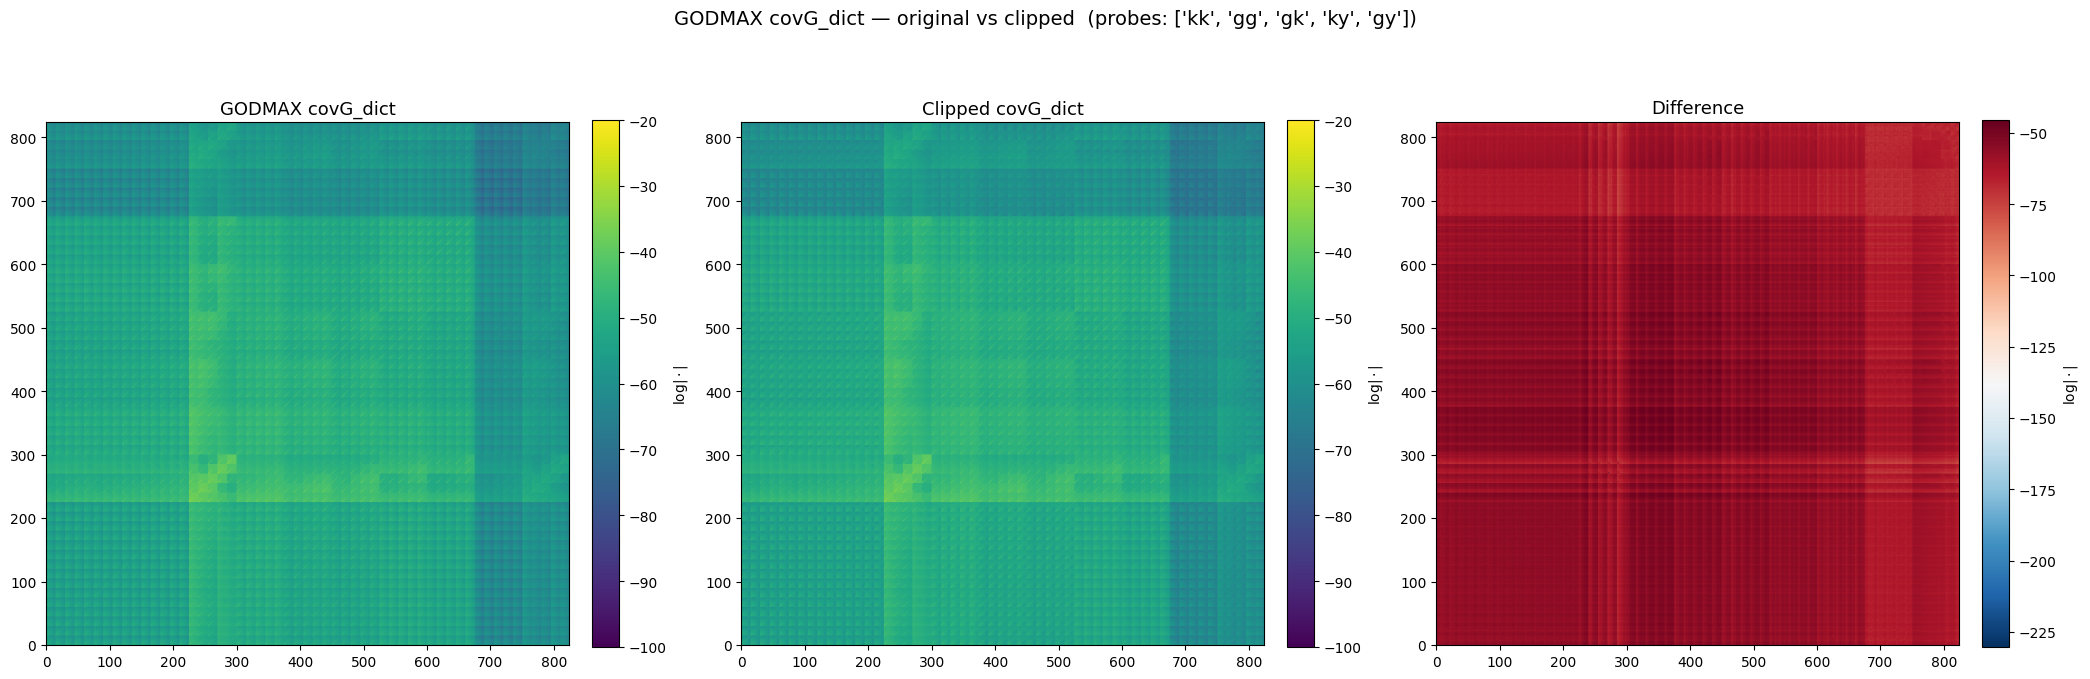

In [33]:
probes_arr = ['gy','gg', 'ky','kk','gk','yy']
probes_arr = ['kk','gg','gk','ky','gy']          
                                                                                                                                                            
# ── Data vector ───────────────────────────────────────────────────────────────                                                                            
dv, entries, nell = diag_utils.build_data_vector(                                                                                                           
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    key='tot_ellsurvey',       # 'tot_plus_noise_ellsurvey' for signal+noise                                                                                
)                                                                                                                                                           

cov, entries, count_per_probe, nell = diag_utils.build_cov_matrix(                                                                                          
    cov_test.covtot_dict,                                                                                                                                   
    cov_test.Cl_result_dict,                                                                                                                                
    probes_arr,                                                                                                                                             
    warn_missing=True,                                                                                                                                      
) 

eigvals, eigvecs = np.linalg.eigh(cov)

if np.any(eigvals < 0):
    n_neg = np.sum(eigvals < 0)
    frac = np.abs(eigvals[eigvals < 0]).max() / eigvals.max()
    print(
        f"WARNING: GODMAX covG_dict has {n_neg} negative eigenvalues "
        f"(max |neg| / max eigval = {frac:.3e})"
    )
    eigvals = np.maximum(eigvals, 0.0)

covtot_clipped = eigvecs @ np.diag(eigvals) @ eigvecs.T
diff = covtot_clipped - cov

# plot the covariance matrices
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

mats = [cov, covtot_clipped, diff]
titles = ["GODMAX covG_dict", "Clipped covG_dict", "Difference"]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(
        np.log(np.abs(mat) + 1e-100),
        origin="lower",
        cmap="RdBu_r" if "Difference" in title else "viridis",
        vmin=(None if "Difference" in title else -100),
        vmax=(None if "Difference" in title else -20),
    )
    plt.colorbar(im, ax=ax, label=r"$\log|\cdot|$", fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)

fig.suptitle(
    f"GODMAX covG_dict — original vs clipped  (probes: {probes_arr})",
    fontsize=14, y=1.01
)
fig.tight_layout()
fig.savefig(
    FIGDIR / f"cov_tot_clipped_comparison_{'_'.join(probes_arr)}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


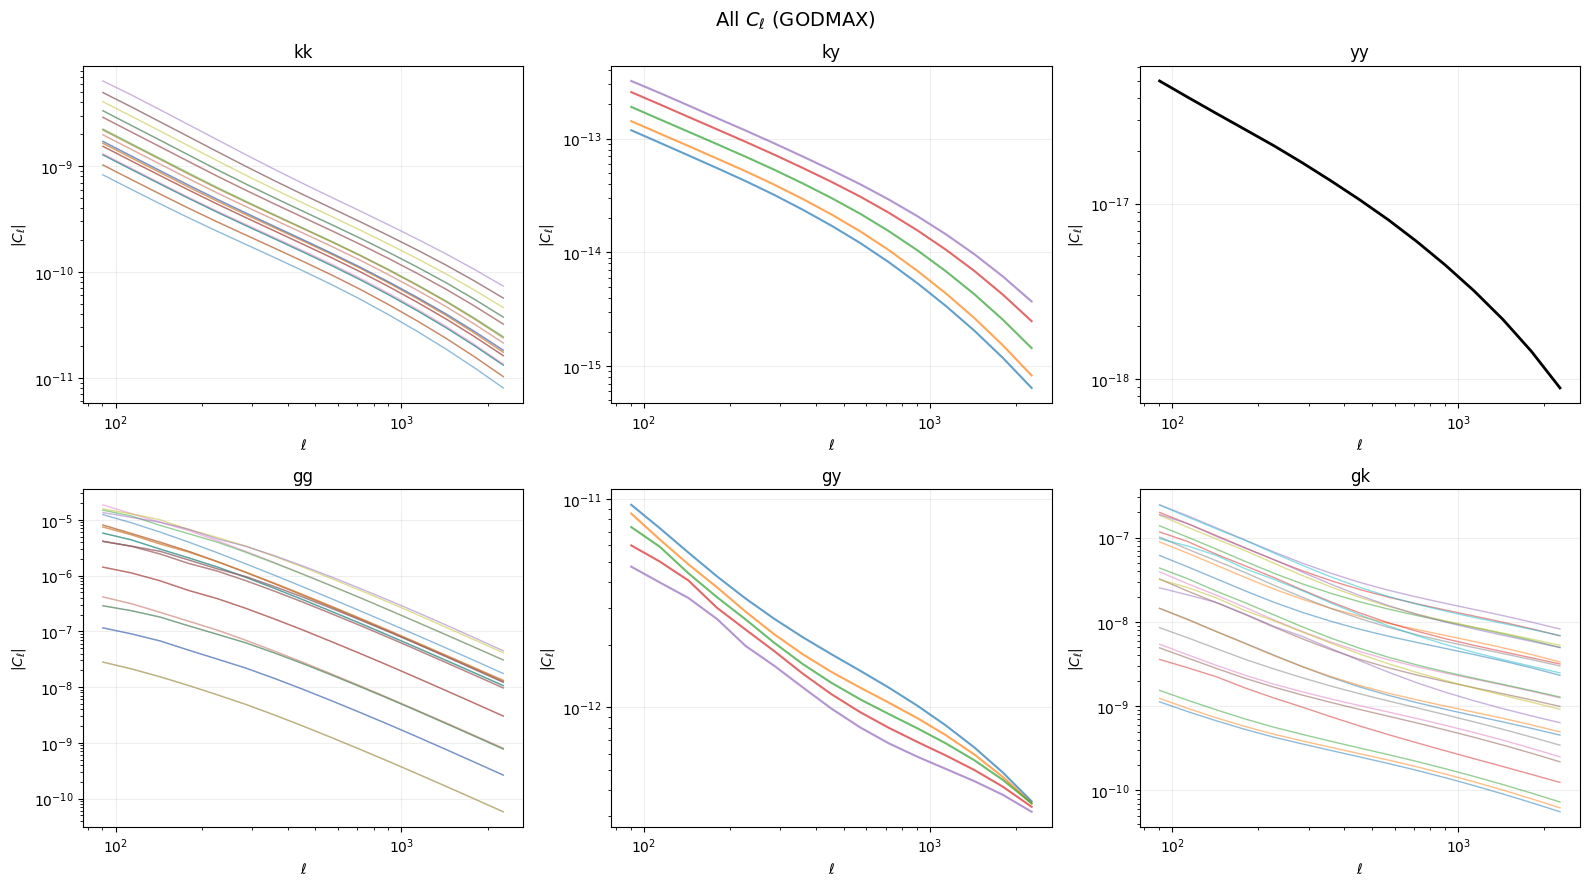

In [37]:
ell = np.array(Cls_test.ell_array) 

Cls_dict = {
    'kk': np.array(Cls_test.Cl_kappa_kappa_tot_mat),   # (nell, nb, nb)
    'ky': np.array(Cls_test.Cl_kappa_y_tot_mat),       # (nell, nb)
    'yy': np.array(Cls_test.Cl_y_y_signal_mat),        # (nell,)
    'gg': np.array(Cls_test.Cl_gal_gal_tot_mat),       # (nell, nb_l, nb_l)
    'gy': np.array(Cls_test.Cl_gal_y_tot_mat),         # (nell, nb_l)
    'gk': np.array(Cls_test.Cl_gal_kappa_tot_mat),     # (nell, nb_l, nb)
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (probe, Cl) in zip(axes, Cls_dict.items()):

    # ---- case 1: auto (matrix) ----
    if Cl.ndim == 3:
        nb1, nb2 = Cl.shape[1], Cl.shape[2]

        for i in range(nb1):
            for j in range(nb2):
                ax.plot(
                    ell,
                    np.abs(Cl[:, i, j]),
                    lw=1,
                    alpha=0.5,
                )

    # ---- case 2: cross (vector) ----
    elif Cl.ndim == 2:
        nb = Cl.shape[1]
        for i in range(nb):
            ax.plot(
                ell,
                np.abs(Cl[:, i]),
                lw=1.5,
                alpha=0.7,
            )

    # ---- case 3: scalar ----
    elif Cl.ndim == 1:
        ax.plot(
            ell,
            np.abs(Cl),
            lw=2,
            color='black',
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(probe, fontsize=12)
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$|C_\ell|$')
    ax.grid(alpha=0.2)

fig.suptitle("All $C_\\ell$ (GODMAX)", fontsize=14)
fig.tight_layout()
#fix the path of fig saving
fig.savefig(FIGDIR / "all_cls_overview.png", dpi=200, bbox_inches="tight")
# fig.savefig(FIGDIR + "all_cls_overview.png", dpi=200, bbox_inches="tight")
plt.show()